Selected 50 files (seed=42)
  1 - /content/drive/MyDrive/Mutiny_dataset 2/baseline/17_deploy/kube-system_kube-apiserver-ubuntu_9be504c70c56444db758f8dbddfcbd9d/kube-apiserver/90.log
  2 - /content/drive/MyDrive/Mutiny_dataset 2/baseline/7_availab/kube-system_kube-apiserver-ubuntu_9be504c70c56444db758f8dbddfcbd9d/kube-apiserver/62.log
  3 - /content/drive/MyDrive/Mutiny_dataset 2/baseline/9_deploy/kube-system_kube-scheduler-ubuntu_bc330090f361a5cbf1975389a51dc450/kube-scheduler/66.log
  4 - /content/drive/MyDrive/Mutiny_dataset 2/baseline/14_deploy/kube-system_kube-controller-manager-ubuntu_c906213ed5e7e093df3a28b477fe870a/kube-controller-manager/81.log
  5 - /content/drive/MyDrive/Mutiny_dataset 2/baseline/2_deploy/kube-system_kube-apiserver-ubuntu_9be504c70c56444db758f8dbddfcbd9d/kube-apiserver/45.log
  6 - /content/drive/MyDrive/Mutiny_dataset 2/baseline/2_scale/kube-system_kube-scheduler-ubuntu_bc330090f361a5cbf1975389a51dc450/kube-scheduler/46.log
  7 - /content/drive/MyDrive/Mutin

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


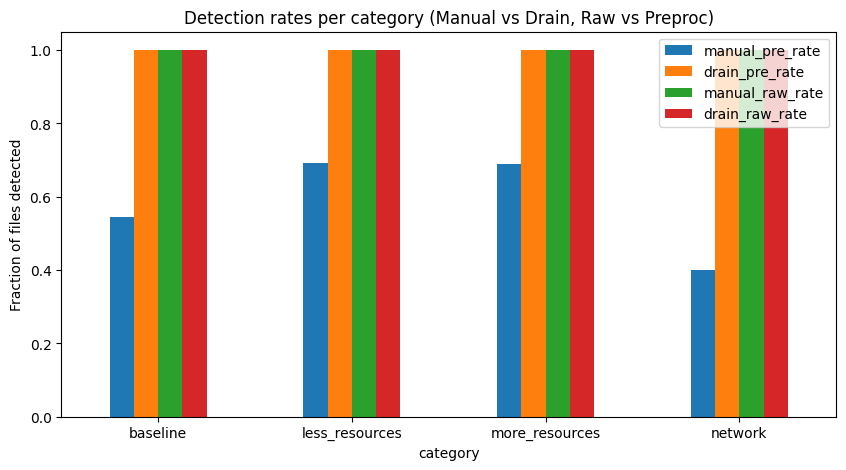


Top suspicious clusters (preproc): 14 found. Showing up to 10:
[CID 16] size=13456 keywords=4107 -> <timestamp> stderr F <idate> <*> 1 httplog.go:132] "HTTP" <*> <*> <*> <*> (linux/amd64) <*> audit-ID="<audit_id>" srcIP="<ip_addr>" <*> <*> <*> apf_fseats=0 apf_additionalLatency="0s" <*> <*>
[CID 25] size=258 keywords=258 -> <timestamp> stderr F <idate> <*> 1 secure_serving.go:296] http: TLS handshake error from <ip_addr>: tls: client offered only unsupported versions: []
[CID 64] size=134 keywords=134 -> <timestamp> stderr F <idate> <*> 1 get.go:260] "Starting watch" <*> <*> <*> <*> <*>
[CID 82] size=167 keywords=167 -> <timestamp> stderr F <idate> <*> 1 <*> <*> of <*> failed because of a conflict, going to retry
[CID 96] size=38 keywords=38 -> <timestamp> stderr F <idate> <*> 1 controlbuf.go:529] "[transport] transport: loopyWriter.run returning. connection error: desc = \"transport is closing\"\n"
[CID 97] size=59 keywords=59 -> <timestamp> stderr F <idate> <*> 1 httplog.go:132] "HT

In [ ]:
# =========================
# Colab-ready: RAW vs PREPROC, Manual vs Drain (50 file bilanciati)
# =========================

# Install dependencies (esegui la cella; commenta se già installato)
!pip install drain3 statsmodels scikit-learn > /dev/null

import os, random, re, time
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Drain & stats imports
from drain3 import TemplateMiner
from drain3.file_persistence import FilePersistence
from drain3.template_miner_config import TemplateMinerConfig
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score

# -------------------------
# CONFIGURAZIONE
# -------------------------
BASE_DIR = "/content/drive/MyDrive/Mutiny_dataset 2"   # cambia se necessario
CATEGORIES = ["baseline", "less_resources", "more_resources", "network"]
FILES_PER_CATEGORY = 10
EXTRA_FILES = 10
SEED = 42
random.seed(SEED)
KEYWORDS = ["error","fail","failed","exception","timeout","panic","crash","unavailable","refused"]

# Regole scelte (option B / B)
MIN_MANUAL_HITS = 3
MIN_MANUAL_PCT = 0.001   # 0.1%
CLUSTER_KEYWORD_PCT = 0.01   # 1%
MIN_CLUSTER_SIZE = 3

# -------------------------
# Preprocessing function
# -------------------------
def preprocess_k8s_log(log_line):
    if not log_line or not log_line.strip():
        return ""
    content = log_line.strip()
    # TIMESTAMP
    content = re.sub(r'^\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}\.\d+([+-]\d{2}:\d{2}|[Zz])?', '<timestamp>', content)
    content = re.sub(r'^\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}([+-]\d{2}:\d{2}|[Zz])?', '<timestamp>', content)
    content = re.sub(r't=\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\.\d+', 't=<timestamp>', content, flags=re.IGNORECASE)
    content = re.sub(r'\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}\.\d+[Zz]?', '<timestamp>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', '<date>', content)
    content = re.sub(r'\b[iI]\d{4}\b', '<idate>', content)
    # NETWORK
    content = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?\b', '<ip_addr>', content)
    content = re.sub(r'\[::1\](:\d+)?', '<ip_addr>', content)
    content = re.sub(r'https?://[^\s/$.?#].[^\s]*', 'https://<ip_addr>', content, flags=re.IGNORECASE)
    # IDENTIFICATORI
    content = re.sub(r'\b[a-f0-9]{8}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{12}\b', '<uuid>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b[a-f0-9]{32,}\b', '<hash>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b[a-f0-9]{16,31}\b', '<hash>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b([a-zA-Z][a-zA-Z0-9-]*)-[a-f0-9]{5,}(-[a-z0-9]+)?\b', r'\1-<pod_id>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b([a-zA-Z][a-zA-Z0-9-]*)-[a-f0-9]{8,10}\b', r'\1-<rs_id>', content, flags=re.IGNORECASE)
    content = re.sub(r'audit-ID="[^"]*"', 'audit-ID="<audit_id>"', content, flags=re.IGNORECASE)
    content = re.sub(r'uid="[^"]*"', 'uid="<uuid>"', content, flags=re.IGNORECASE)
    content = re.sub(r'resource[vV]ersion[=:]["?\d+"?]?', 'resourceVersion="<res_ver>"', content, flags=re.IGNORECASE)
    content = re.sub(r'node[=:"][^"]*"?', 'node="<node_name>"', content, flags=re.IGNORECASE)
    # NUMERI
    content = re.sub(r'\b\d{10,}\b(?![.%])', '<large_num>', content)
    content = re.sub(r'\b\d{8,9}\b(?![.%ms])', '<num_id>', content)
    return re.sub(r'\s+', ' ', content).strip()

# -------------------------
# Helper: collect balanced subset files
# -------------------------
def collect_balanced_files(base_dir, categories, per_cat, extra):
    all_files = []
    chosen = []
    for cat in categories:
        cat_dir = os.path.join(base_dir, cat)
        if not os.path.isdir(cat_dir):
            continue
        cat_files = []
        for root, _, files in os.walk(cat_dir):
            for f in files:
                if f.endswith(".log"):
                    cat_files.append(os.path.join(root, f).strip())
        if not cat_files:
            continue
        sample = random.sample(cat_files, min(per_cat, len(cat_files)))
        chosen.extend(sample)
        all_files.extend(cat_files)
    if extra > 0 and len(all_files) > 0:
        extra_sample = random.sample(all_files, min(extra, len(all_files)))
        chosen.extend(extra_sample)
    # deduplicate and return
    chosen = list(dict.fromkeys(chosen))
    return chosen

# -------------------------
# Small utilities
# -------------------------
def manual_detect_rule(matches, total_lines):
    if matches >= MIN_MANUAL_HITS:
        return True
    if total_lines > 0 and (matches / total_lines) >= MIN_MANUAL_PCT:
        return True
    return False

# -------------------------
# MAIN: run experiment for a given mode ("raw" or "preproc")
# returns DataFrame with per-file results and cluster metadata
# -------------------------
def run_mode(mode, subset_files, keywords):
    """
    mode: "raw" or "preproc"
    subset_files: list of file paths
    returns: df (per-file records), cluster_info (dict cluster_id -> {total, keyword_count, template})
    """
    # init Drain (fresh state per run)
    config = TemplateMinerConfig()
    config.profiling_enabled = False
    config.drain_sim_th = 0.5
    config.drain_depth = 4
    persistence = FilePersistence(f"drain_state_{mode}.json")
    miner = TemplateMiner(persistence, config)

    # cluster counters (aggregate across all processed lines)
    cluster_total = Counter()
    cluster_keyword = Counter()
    # mapping file -> set of cluster ids seen in that file
    file_clusters = defaultdict(set)

    records = []
    total_lines = 0
    manual_total_matches = 0

    for file_path in subset_files:
        file_path = file_path.strip()
        if not os.path.exists(file_path):
            print("[WARN] file not found:", file_path)
            continue

        file_lines = 0
        file_manual_matches = 0
        file_cluster_ids = set()

        with open(file_path, "r", errors="ignore") as fh:
            for line in fh:
                total_lines += 1
                file_lines += 1

                if mode == "preproc":
                    proc = preprocess_k8s_log(line)
                else:
                    proc = line.strip()

                # manual keyword-based (case-insensitive)
                low = proc.lower()
                if any(k in low for k in keywords):
                    file_manual_matches += 1
                    manual_total_matches += 1

                # Drain parsing
                if proc:
                    res = miner.add_log_message(proc)
                    # miner returns cluster_id
                    cid = res.get("cluster_id", None)
                    if cid is not None:
                        file_cluster_ids.add(cid)
                        cluster_total[cid] += 1
                        if any(k in low for k in keywords):
                            cluster_keyword[cid] += 1

        # file-level decisions
        manual_detected = manual_detect_rule(file_manual_matches, file_lines)
        # Drain detection per-file will be decided after computing suspicious clusters (global)
        records.append({
            "file": file_path,
            "category": next((c for c in CATEGORIES if f"/{c}/" in file_path), "unknown"),
            "component": os.path.basename(os.path.dirname(file_path)),  # last dir before filename
            "mode": mode,
            "total_lines": file_lines,
            "manual_matches": file_manual_matches,
            "manual_detected": manual_detected,
            "cluster_ids": file_cluster_ids
        })

    # after processing all files, compute suspicious clusters by rule
    suspicious_clusters = set()
    for cid, tot in cluster_total.items():
        kcount = cluster_keyword.get(cid, 0)
        if tot >= MIN_CLUSTER_SIZE and (kcount / tot) >= CLUSTER_KEYWORD_PCT:
            suspicious_clusters.add(cid)

    # attach drain-derived fields to records
    for rec in records:
        cids = rec["cluster_ids"]
        rec["drain_num_clusters_seen"] = len(cids)
        # how many of seen clusters are suspicious
        rec["drain_num_suspicious_clusters_seen"] = len([cid for cid in cids if cid in suspicious_clusters])
        rec["drain_detected"] = rec["drain_num_suspicious_clusters_seen"] > 0

    # build cluster info dict with templates
    cluster_info = {}
    # miner.drain.clusters is iterable of Cluster objects
    for cluster in miner.drain.clusters:
        cluster_info[cluster.cluster_id] = {
            "cluster_id": cluster.cluster_id,
            "size": cluster.size,
            "template": cluster.get_template(),
            "keyword_count": int(cluster_keyword.get(cluster.cluster_id, 0)),
            "is_suspicious": (cluster.cluster_id in suspicious_clusters)
        }

    df = pd.DataFrame(records)
    return df, cluster_info, miner

# -------------------------
# Run full experiment (balanced 50 files)
# -------------------------
subset_files = collect_balanced_files(BASE_DIR, CATEGORIES, FILES_PER_CATEGORY, EXTRA_FILES)
print(f"Selected {len(subset_files)} files (seed={SEED})")
for i,f in enumerate(subset_files[:10]): print(" ",i+1,"-", f)

# Run RAW
t0 = time.time()
df_raw, clusters_raw, miner_raw = run_mode("raw", subset_files, KEYWORDS)
print("RAW done in {:.1f}s".format(time.time()-t0))

# Run PREPROC
t0 = time.time()
df_pre, clusters_pre, miner_pre = run_mode("preproc", subset_files, KEYWORDS)
print("PREPROC done in {:.1f}s".format(time.time()-t0))

# -------------------------
# Combine results: per-file comparison (raw vs preproc)
# -------------------------
df_comb = pd.merge(
    df_raw.add_suffix("_raw"),
    df_pre.add_suffix("_pre"),
    left_on="file_raw",
    right_on="file_pre",
    how="outer"
)

# Normalize column names
df_comb = df_comb.rename(columns={"file_raw":"file", "category_raw":"category", "component_raw":"component"})
# fillna for booleans
df_comb["manual_detected_raw"] = df_comb["manual_detected_raw"].fillna(False)
df_comb["manual_detected_pre"] = df_comb["manual_detected_pre"].fillna(False)
df_comb["drain_detected_raw"] = df_comb["drain_detected_raw"].fillna(False)
df_comb["drain_detected_pre"] = df_comb["drain_detected_pre"].fillna(False)

# Add ground truth for fault injection (proxy): all non-baseline considered 'injected' for this experiment
df_comb["is_fault_injection"] = df_comb["category"].apply(lambda x: x in ["less_resources","more_resources","network"])

# -------------------------
# Metrics for fault-injection files (precision/recall for each method)
# -------------------------
def compute_binary_metrics(y_true, y_pred):
    # y_true/y_pred are binary arrays
    tp = int(((y_true==1) & (y_pred==1)).sum())
    fp = int(((y_true==0) & (y_pred==1)).sum())
    fn = int(((y_true==1) & (y_pred==0)).sum())
    tn = int(((y_true==0) & (y_pred==0)).sum())
    precision = tp / (tp+fp) if (tp+fp)>0 else np.nan
    recall = tp / (tp+fn) if (tp+fn)>0 else np.nan
    f1 = 2*precision*recall/(precision+recall) if precision and recall and (precision+recall)>0 else np.nan
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":precision,"recall":recall,"f1":f1}

fault_mask = df_comb["is_fault_injection"]==True
print("\n-- Fault-injection subset metrics (proxy ground truth) --")
for method in [("manual_detected_pre","Manual (preproc)"),("drain_detected_pre","Drain (preproc)"),
               ("manual_detected_raw","Manual (raw)"),("drain_detected_raw","Drain (raw)")]:
    col, name = method
    res = compute_binary_metrics(df_comb.loc[fault_mask, "is_fault_injection"].astype(int), df_comb.loc[fault_mask, col].astype(int))
    print(f"{name}: precision={res['precision']:.3f}, recall={res['recall']:.3f}, f1={res['f1']:.3f}, tp={res['tp']}, fp={res['fp']}, fn={res['fn']}")

# -------------------------
# Agreement on baseline: Cohen's kappa between manual and drain (preproc)
# -------------------------
baseline_mask = df_comb["category"]=="baseline"
if baseline_mask.sum() > 0:
    kappa_pre = cohen_kappa_score(df_comb.loc[baseline_mask,"manual_detected_pre"].astype(int),
                                  df_comb.loc[baseline_mask,"drain_detected_pre"].astype(int))
    kappa_raw = cohen_kappa_score(df_comb.loc[baseline_mask,"manual_detected_raw"].astype(int),
                                  df_comb.loc[baseline_mask,"drain_detected_raw"].astype(int))
    print(f"\nBaseline agreement (Cohen's kappa): preproc={kappa_pre:.3f}, raw={kappa_raw:.3f}")

# -------------------------
# McNemar test (paired) between Manual and Drain on preproc (overall)
# -------------------------
# Build contingency table
a = int(((df_comb["manual_detected_pre"]) & (df_comb["drain_detected_pre"])).sum())  # both yes
b = int(((df_comb["manual_detected_pre"]) & (~df_comb["drain_detected_pre"])).sum())  # manual yes, drain no
c = int((~(df_comb["manual_detected_pre"]) & (df_comb["drain_detected_pre"])).sum())  # manual no, drain yes
d = int((~(df_comb["manual_detected_pre"]) & (~df_comb["drain_detected_pre"])).sum())  # both no
table = [[a,b],[c,d]]
try:
    mres = mcnemar(table, exact=False)
    print(f"\nMcNemar test (Manual vs Drain on preproc): statistic={mres.statistic:.3f}, p-value={mres.pvalue:.4f}")
except Exception as e:
    print("McNemar test error:", e)

# -------------------------
# Quick visualization (summary)
# -------------------------
# Mean detection rates per category for methods
summary = []
for cat in df_comb["category"].unique():
    mask = df_comb["category"]==cat
    summary.append({
        "category": cat,
        "manual_pre_rate": df_comb.loc[mask,"manual_detected_pre"].mean(),
        "drain_pre_rate": df_comb.loc[mask,"drain_detected_pre"].mean(),
        "manual_raw_rate": df_comb.loc[mask,"manual_detected_raw"].mean(),
        "drain_raw_rate": df_comb.loc[mask,"drain_detected_raw"].mean()
    })
summary_df = pd.DataFrame(summary).set_index("category")
print("\nDetection rates per category (mean of file-level detection):")
print(summary_df)

summary_df.plot(kind="bar", figsize=(10,5), rot=0, title="Detection rates per category (Manual vs Drain, Raw vs Preproc)")
plt.ylabel("Fraction of files detected")
plt.show()

# -------------------------
# Print some suspicious clusters (preproc) - top 10
# -------------------------
susp_pre = [cid for cid,info in clusters_pre.items() if info["is_suspicious"]]
print(f"\nTop suspicious clusters (preproc): {len(susp_pre)} found. Showing up to 10:")
for cid in list(susp_pre)[:10]:
    info = clusters_pre[cid]
    print(f"[CID {cid}] size={info['size']} keywords={info['keyword_count']} -> {info['template'][:300]}")

# -------------------------
# Save aggregated df for inspection (optional)
# -------------------------
# df_comb.to_csv("/content/drive/MyDrive/mutiny_analysis_comparison_50files.csv", index=False)
print("\nDone. Dataframe 'df_comb' contains per-file results for further inspection.")


In [ ]:
# =========================
# SETUP - Esegui sempre per primo
# =========================
!pip install drain3 statsmodels scikit-learn > /dev/null

import os, random, re, time
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from drain3 import TemplateMiner
from drain3.file_persistence import FilePersistence
from drain3.template_miner_config import TemplateMinerConfig
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import cohen_kappa_score

# Configurazione globale
BASE_DIR = "/content/drive/MyDrive/Mutiny_dataset 2"
CATEGORIES = ["baseline", "less_resources", "more_resources", "network"]
SEED = 42
random.seed(SEED)

print("Setup completato")


✓ Setup completato


In [ ]:
# =========================
# FUNZIONI UTILITY
# =========================

def preprocess_k8s_log(log_line):
    """NON MODIFICARE - funzione originale"""
    if not log_line or not log_line.strip():
        return ""
    content = log_line.strip()
    content = re.sub(r'^\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}\.\d+([+-]\d{2}:\d{2}|[Zz])?', '<timestamp>', content)
    content = re.sub(r'^\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}([+-]\d{2}:\d{2}|[Zz])?', '<timestamp>', content)
    content = re.sub(r't=\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\.\d+', 't=<timestamp>', content, flags=re.IGNORECASE)
    content = re.sub(r'\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}\.\d+[Zz]?', '<timestamp>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', '<date>', content)
    content = re.sub(r'\b[iI]\d{4}\b', '<idate>', content)
    content = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?\b', '<ip_addr>', content)
    content = re.sub(r'\[::1\](:\d+)?', '<ip_addr>', content)
    content = re.sub(r'https?://[^\s/$.?#].[^\s]*', 'https://<ip_addr>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b[a-f0-9]{8}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{12}\b', '<uuid>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b[a-f0-9]{32,}\b', '<hash>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b[a-f0-9]{16,31}\b', '<hash>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b([a-zA-Z][a-zA-Z0-9-]*)-[a-f0-9]{5,}(-[a-z0-9]+)?\b', r'\1-<pod_id>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b([a-zA-Z][a-zA-Z0-9-]*)-[a-f0-9]{8,10}\b', r'\1-<rs_id>', content, flags=re.IGNORECASE)
    content = re.sub(r'audit-ID="[^"]*"', 'audit-ID="<audit_id>"', content, flags=re.IGNORECASE)
    content = re.sub(r'uid="[^"]*"', 'uid="<uuid>"', content, flags=re.IGNORECASE)
    content = re.sub(r'resource[vV]ersion[=:]["?\d+"?]?', 'resourceVersion="<res_ver>"', content, flags=re.IGNORECASE)
    content = re.sub(r'node[=:"][^"]*"?', 'node="<node_name>"', content, flags=re.IGNORECASE)
    content = re.sub(r'\b\d{10,}\b(?![.%])', '<large_num>', content)
    content = re.sub(r'\b\d{8,9}\b(?![.%ms])', '<num_id>', content)
    return re.sub(r'\s+', ' ', content).strip()

def analyze_dataset_structure(base_dir, categories):
    """Analizza struttura completa dataset"""
    structure = {}
    for cat in categories:
        cat_dir = os.path.join(base_dir, cat)
        if not os.path.isdir(cat_dir):
            continue
        scenarios = {}
        for item in os.listdir(cat_dir):
            scenario_path = os.path.join(cat_dir, item)
            if os.path.isdir(scenario_path):
                components = defaultdict(int)
                for root, dirs, files in os.walk(scenario_path):
                    for comp in ["kube-apiserver", "kube-scheduler", "kube-controller-manager"]:
                        if comp in root:
                            log_files = [f for f in os.listdir(root) if f.endswith(".log")]
                            components[comp] += len(log_files)
                            break
                scenarios[item] = dict(components)
        structure[cat] = {
            'num_scenarios': len(scenarios),
            'scenarios': scenarios,
            'total_components': sum(len(s) for s in scenarios.values())
        }
    return structure

def collect_stratified_balanced_files(base_dir, categories, target_per_category):
    """Campionamento stratificato bilanciato"""
    all_selected = []
    selection_log = defaultdict(lambda: defaultdict(list))

    for cat in categories:
        cat_dir = os.path.join(base_dir, cat)
        if not os.path.isdir(cat_dir):
            continue
        scenarios = [d for d in os.listdir(cat_dir) if os.path.isdir(os.path.join(cat_dir, d))]
        if not scenarios:
            continue

        scenario_files = []
        for scenario in scenarios:
            scenario_path = os.path.join(cat_dir, scenario)
            for root, dirs, files in os.walk(scenario_path):
                comp = None
                if "kube-apiserver" in root:
                    comp = "kube-apiserver"
                elif "kube-scheduler" in root:
                    comp = "kube-scheduler"
                elif "kube-controller-manager" in root:
                    comp = "kube-controller-manager"

                if comp:
                    log_files = [f for f in files if f.endswith(".log")]
                    if log_files:
                        selected_log = random.choice(log_files)
                        full_path = os.path.join(root, selected_log)
                        scenario_files.append({
                            'path': full_path,
                            'category': cat,
                            'scenario': scenario,
                            'component': comp
                        })

        files_per_component = target_per_category // 3
        selected_for_cat = []
        for comp in ["kube-apiserver", "kube-scheduler", "kube-controller-manager"]:
            comp_files = [f for f in scenario_files if f['component'] == comp]
            sample_size = min(files_per_component, len(comp_files))
            sampled = random.sample(comp_files, sample_size)
            selected_for_cat.extend(sampled)
            for item in sampled:
                selection_log[cat][comp].append(item['scenario'])

        all_selected.extend(selected_for_cat)

    selected_paths = [item['path'] for item in all_selected]
    return selected_paths, selection_log

print("Funzioni utility caricate")


✓ Funzioni utility caricate


In [ ]:
# =========================
# FASE 1: CAMPIONAMENTO E VERIFICA DISTRIBUZIONE
# Tempo stimato: 1-3 minuti
# =========================

FILES_PER_CATEGORY = 60  # ~240 file totali (60 x 4 categorie, bilanciati per componente)

print("=" * 70)
print("FASE 1: ANALISI STRUTTURA E CAMPIONAMENTO")
print("=" * 70)

# Step 1: Analisi struttura completa (opzionale, ma utile)
print("\n[1/3] Analisi struttura dataset...")
structure = analyze_dataset_structure(BASE_DIR, CATEGORIES)
for cat, info in structure.items():
    print(f"\n{cat}:")
    print(f"  Scenari disponibili: {info['num_scenarios']}")
    print(f"  Componenti totali: {info['total_components']}")
    # Mostra primi 3 scenari come esempio
    for i, (scen, comps) in enumerate(list(info['scenarios'].items())[:3]):
        print(f"    Esempio: {scen} → {comps}")

# Step 2: Campionamento stratificato
print("\n[2/3] Esecuzione campionamento stratificato...")
t0 = time.time()
subset_files, selection_log = collect_stratified_balanced_files(
    BASE_DIR, CATEGORIES, FILES_PER_CATEGORY
)
print(f"Campionamento completato in {time.time()-t0:.1f}s")
print(f"Selezionati {len(subset_files)} file totali\n")

# Step 3: Verifica distribuzione
print("=" * 70)
print("VERIFICA BILANCIAMENTO")
print("=" * 70)

# 1. Per categoria
print("\n[A] Distribuzione per CATEGORIA:")
for cat in CATEGORIES:
    count = sum(1 for f in subset_files if f"/{cat}/" in f or f"\\{cat}\\" in f)
    pct = 100 * count / len(subset_files) if len(subset_files) > 0 else 0
    target = 25.0  # 4 categorie = 25% ciascuna
    status = "✓" if abs(pct - target) <= 5 else "⚠️"
    print(f"  {status} {cat:20s}: {count:3d} files ({pct:5.1f}%) [target: ~25%]")

# 2. Per componente
print("\n[B] Distribuzione per COMPONENTE (globale):")
comp_count = defaultdict(int)
for f in subset_files:
    if "kube-apiserver" in f:
        comp_count["kube-apiserver"] += 1
    elif "kube-scheduler" in f:
        comp_count["kube-scheduler"] += 1
    elif "kube-controller-manager" in f:
        comp_count["kube-controller-manager"] += 1

for comp, count in sorted(comp_count.items()):
    pct = 100 * count / len(subset_files) if len(subset_files) > 0 else 0
    target = 33.3  # 3 componenti = 33.3% ciascuno
    status = "✓" if abs(pct - target) <= 5 else "⚠️"
    print(f"  {status} {comp:30s}: {count:3d} files ({pct:5.1f}%) [target: ~33%]")

# 3. Matrice categoria x componente
print("\n[C] Matrice CATEGORIA x COMPONENTE:")
matrix = defaultdict(lambda: defaultdict(int))
for f in subset_files:
    cat = next((c for c in CATEGORIES if f"/{c}/" in f or f"\\{c}\\" in f), "unknown")
    if "kube-apiserver" in f:
        comp = "apiserver"
    elif "kube-scheduler" in f:
        comp = "scheduler"
    elif "kube-controller-manager" in f:
        comp = "controller"
    else:
        comp = "unknown"
    matrix[cat][comp] += 1

print(f"{'Category':20s} | {'apiserver':>10s} | {'scheduler':>10s} | {'controller':>10s} | {'Total':>10s}")
print("-" * 75)
for cat in CATEGORIES:
    total = sum(matrix[cat].values())
    print(f"{cat:20s} | {matrix[cat]['apiserver']:>10d} | {matrix[cat]['scheduler']:>10d} | {matrix[cat]['controller']:>10d} | {total:>10d}")

# 4. Diversità scenari
print("\n[D] Diversità SCENARI utilizzati per categoria:")
for cat in CATEGORIES:
    scenarios_used = set(selection_log[cat]['kube-apiserver'] +
                        selection_log[cat]['kube-scheduler'] +
                        selection_log[cat]['kube-controller-manager'])
    print(f"  {cat:20s}: {len(scenarios_used)} scenari unici")

# 5. Verifica duplicati
print("\n[E] Verifica DUPLICATI (scenario+componente):")
scenario_comp_pairs = defaultdict(int)
for f in subset_files:
    parts = f.replace('\\', '/').split('/')
    try:
        cat_idx = next(i for i, p in enumerate(parts) if p in CATEGORIES)
        if cat_idx + 1 < len(parts):
            scenario = parts[cat_idx + 1]
            if "kube-apiserver" in f:
                comp = "apiserver"
            elif "kube-scheduler" in f:
                comp = "scheduler"
            elif "kube-controller-manager" in f:
                comp = "controller"
            else:
                continue
            key = f"{parts[cat_idx]}/{scenario}/{comp}"
            scenario_comp_pairs[key] += 1
    except:
        pass

duplicates = {k: v for k, v in scenario_comp_pairs.items() if v > 1}
if duplicates:
    print(f"  ⚠️  TROVATI {len(duplicates)} duplicati:")
    for key, count in sorted(duplicates.items(), key=lambda x: -x[1])[:10]:
        print(f"      - {key}: {count} file")
else:
    print(f"  ✓ Nessun duplicato trovato! Ogni scenario+componente ha al più 1 file.")

print("\n" + "=" * 70)
print("FASE 1 COMPLETATA")
print("=" * 70)
print("\n COPIA E INVIA L'OUTPUT SOPRA PER REVISIONE")
print(" Se approvato, procederai con FASE 2 nella cella successiva")


FASE 1: ANALISI STRUTTURA E CAMPIONAMENTO

[1/3] Analisi struttura dataset...

baseline:
  Scenari disponibili: 78
  Componenti totali: 234
    Esempio: 9_scale → {'kube-scheduler': 1, 'kube-apiserver': 1, 'kube-controller-manager': 1}
    Esempio: 8_deploy → {'kube-controller-manager': 1, 'kube-scheduler': 1, 'kube-apiserver': 1}
    Esempio: 9_deploy → {'kube-scheduler': 1, 'kube-controller-manager': 1, 'kube-apiserver': 1}

less_resources:
  Scenari disponibili: 1
  Componenti totali: 3
    Esempio: 999_99_99_apiserver_to_etc_ordered_127_allfields → {'kube-apiserver': 350, 'kube-scheduler': 350, 'kube-controller-manager': 0}

more_resources:
  Scenari disponibili: 1
  Componenti totali: 3
    Esempio: 999_99_99_apiserver_to_etc_ordered_127_allfields → {'kube-scheduler': 808, 'kube-apiserver': 808, 'kube-controller-manager': 0}

network:
  Scenari disponibili: 1
  Componenti totali: 3
    Esempio: 999_99_99_apiserver_to_etc_ordered_127_allfields → {'kube-scheduler': 115, 'kube-contro

In [ ]:
# =========================
# FASE 2: ANALISI CON PREPROCESSING (SOLO)
# =========================

# Configurazione soglie
KEYWORDS = ["error","fail","failed","exception","timeout","panic","crash","unavailable","refused"]
MIN_MANUAL_HITS = 8
MIN_MANUAL_PCT = 0.003  # 0.3%
CLUSTER_KEYWORD_PCT = 0.03  # 3%
MIN_CLUSTER_SIZE = 5
MAX_CLUSTER_SIZE_RATIO = 0.08  # 8%

def manual_detect_rule(matches, total_lines):
    """Regola di detection manuale"""
    if matches >= MIN_MANUAL_HITS:
        return True
    if total_lines > 0 and (matches / total_lines) >= MIN_MANUAL_PCT:
        return True
    return False

def compute_binary_metrics(y_true, y_pred):
    """Calcolo metriche binarie"""
    tp = int(((y_true==1) & (y_pred==1)).sum())
    fp = int(((y_true==0) & (y_pred==1)).sum())
    fn = int(((y_true==1) & (y_pred==0)).sum())
    tn = int(((y_true==0) & (y_pred==0)).sum())
    precision = tp / (tp+fp) if (tp+fp)>0 else 0.0
    recall = tp / (tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":precision,"recall":recall,"f1":f1}

def run_mode(mode, subset_files, keywords):
    """Esegue parsing e detection per modalità specificata"""
    config = TemplateMinerConfig()
    config.profiling_enabled = False
    config.drain_sim_th = 0.6
    config.drain_depth = 4
    persistence = FilePersistence(f"drain_state_{mode}.json")
    miner = TemplateMiner(persistence, config)

    cluster_total = Counter()
    cluster_keyword = Counter()
    records = []

    print(f"\n[{mode.upper()}] Inizio processing di {len(subset_files)} file...")
    processed = 0

    for file_path in subset_files:
        file_path = file_path.strip()
        if not os.path.exists(file_path):
            print(f"[WARN] file not found: {file_path}")
            continue

        file_lines = 0
        file_manual_matches = 0
        file_cluster_ids = set()

        with open(file_path, "r", errors="ignore") as fh:
            for line in fh:
                file_lines += 1
                if mode == "preproc":
                    proc = preprocess_k8s_log(line)
                else:
                    proc = line.strip()

                low = proc.lower()
                if any(k in low for k in keywords):
                    file_manual_matches += 1

                if proc:
                    res = miner.add_log_message(proc)
                    cid = res.get("cluster_id", None)
                    if cid is not None:
                        file_cluster_ids.add(cid)
                        cluster_total[cid] += 1
                        if any(k in low for k in keywords):
                            cluster_keyword[cid] += 1

        manual_detected = manual_detect_rule(file_manual_matches, file_lines)

        # Estrai categoria e componente
        cat = next((c for c in CATEGORIES if f"/{c}/" in file_path or f"\\{c}\\" in file_path), "unknown")
        if "kube-apiserver" in file_path:
            comp = "kube-apiserver"
        elif "kube-scheduler" in file_path:
            comp = "kube-scheduler"
        elif "kube-controller-manager" in file_path:
            comp = "kube-controller-manager"
        else:
            comp = "unknown"

        records.append({
            "file": file_path,
            "category": cat,
            "component": comp,
            "mode": mode,
            "total_lines": file_lines,
            "manual_matches": file_manual_matches,
            "manual_detected": manual_detected,
            "cluster_ids": file_cluster_ids
        })

        processed += 1
        if processed % 50 == 0:
            print(f"  Progress: {processed}/{len(subset_files)} files...")

    # Identifica cluster sospetti con filtro dimensione
    suspicious_clusters = set()
    total_all_lines = sum(cluster_total.values())
    print(f"[{mode.upper()}] Total lines: {total_all_lines:,}, Total clusters: {len(cluster_total)}")

    for cid, tot in cluster_total.items():
        kcount = cluster_keyword.get(cid, 0)
        if tot < MIN_CLUSTER_SIZE:
            continue
        if total_all_lines > 0 and (tot / total_all_lines) > MAX_CLUSTER_SIZE_RATIO:
            continue  # Skip cluster troppo grandi
        if tot > 0 and (kcount / tot) >= CLUSTER_KEYWORD_PCT:
            suspicious_clusters.add(cid)

    print(f"[{mode.upper()}] Suspicious clusters identified: {len(suspicious_clusters)}")

    # Attacca info Drain ai record
    for rec in records:
        cids = rec["cluster_ids"]
        rec["drain_num_clusters_seen"] = len(cids)
        rec["drain_num_suspicious_clusters_seen"] = len([cid for cid in cids if cid in suspicious_clusters])
        rec["drain_detected"] = rec["drain_num_suspicious_clusters_seen"] > 0

    # Cluster info
    cluster_info = {}
    for cluster in miner.drain.clusters:
        cluster_info[cluster.cluster_id] = {
            "cluster_id": cluster.cluster_id,
            "size": cluster.size,
            "template": cluster.get_template(),
            "keyword_count": int(cluster_keyword.get(cluster.cluster_id, 0)),
            "is_suspicious": (cluster.cluster_id in suspicious_clusters)
        }

    df = pd.DataFrame(records)
    # RITORNA ANCHE cluster_total per visualizzazione finale
    return df, cluster_info, miner, cluster_total

# -------------------------
# ESECUZIONE
# -------------------------
print("=" * 70)
print("FASE 2: ANALISI CON PREPROCESSING")
print("=" * 70)
print(f"\nParametri:")
print(f"  Dataset: {len(subset_files)} file")
print(f"  Manual: MIN_HITS={MIN_MANUAL_HITS}, MIN_PCT={MIN_MANUAL_PCT}")
print(f"  Drain:  sim_th={0.6}, depth={4}")
print(f"  Cluster: MIN_SIZE={MIN_CLUSTER_SIZE}, MAX_RATIO={MAX_CLUSTER_SIZE_RATIO}, KEYWORD_PCT={CLUSTER_KEYWORD_PCT}")

t0 = time.time()
df_pre, clusters_pre, miner_pre, cluster_total_pre = run_mode("preproc", subset_files, KEYWORDS)
elapsed = time.time() - t0
print(f"\n✓ Processing completato in {elapsed:.1f}s ({elapsed/len(subset_files):.2f}s/file)")

# -------------------------
# METRICHE
# -------------------------
df_pre["is_fault_injection"] = df_pre["category"].apply(lambda x: x in ["less_resources","more_resources","network"])

print("\n" + "=" * 70)
print("METRICHE SU FILE FAULT INJECTION")
print("=" * 70)

fault_mask = df_pre["is_fault_injection"] == True
n_fault = fault_mask.sum()
print(f"\nFile fault injection: {n_fault}/{len(df_pre)} ({100*n_fault/len(df_pre):.1f}%)")

manual_res = compute_binary_metrics(
    df_pre.loc[fault_mask, "is_fault_injection"].astype(int),
    df_pre.loc[fault_mask, "manual_detected"].astype(int)
)
drain_res = compute_binary_metrics(
    df_pre.loc[fault_mask, "is_fault_injection"].astype(int),
    df_pre.loc[fault_mask, "drain_detected"].astype(int)
)

print(f"\nManual (preproc):")
print(f"  Precision: {manual_res['precision']:.3f}")
print(f"  Recall:    {manual_res['recall']:.3f}")
print(f"  F1-score:  {manual_res['f1']:.3f}")
print(f"  Confusion: TP={manual_res['tp']}, FP={manual_res['fp']}, FN={manual_res['fn']}, TN={manual_res['tn']}")

print(f"\nDrain (preproc):")
print(f"  Precision: {drain_res['precision']:.3f}")
print(f"  Recall:    {drain_res['recall']:.3f}")
print(f"  F1-score:  {drain_res['f1']:.3f}")
print(f"  Confusion: TP={drain_res['tp']}, FP={drain_res['fp']}, FN={drain_res['fn']}, TN={drain_res['tn']}")

# Delta
print(f"\nΔ Drain vs Manual:")
print(f"  Precision: {drain_res['precision'] - manual_res['precision']:+.3f}")
print(f"  Recall:    {drain_res['recall'] - manual_res['recall']:+.3f}")
print(f"  F1-score:  {drain_res['f1'] - manual_res['f1']:+.3f}")

# -------------------------
# DETECTION RATE PER CATEGORIA
# -------------------------
print("\n" + "=" * 70)
print("DETECTION RATE PER CATEGORIA")
print("=" * 70)
for cat in CATEGORIES:
    mask = df_pre["category"] == cat
    n_files = mask.sum()
    manual_rate = df_pre.loc[mask, "manual_detected"].mean()
    drain_rate = df_pre.loc[mask, "drain_detected"].mean()
    manual_count = df_pre.loc[mask, "manual_detected"].sum()
    drain_count = df_pre.loc[mask, "drain_detected"].sum()

    print(f"\n{cat} ({n_files} files):")
    print(f"  Manual: {manual_rate:5.1%} ({manual_count}/{n_files})")
    print(f"  Drain:  {drain_rate:5.1%} ({drain_count}/{n_files})")

# -------------------------
# PER COMPONENTE (fault injection only)
# -------------------------
print("\n" + "=" * 70)
print("METRICHE PER COMPONENTE (solo fault injection)")
print("=" * 70)
for comp in ["kube-apiserver", "kube-scheduler", "kube-controller-manager"]:
    mask = (df_pre["component"] == comp) & (df_pre["is_fault_injection"] == True)
    n_files = mask.sum()
    if n_files < 3:
        print(f"\n{comp}: skipped (solo {n_files} file)")
        continue

    manual_comp = compute_binary_metrics(
        df_pre.loc[mask, "is_fault_injection"].astype(int),
        df_pre.loc[mask, "manual_detected"].astype(int)
    )
    drain_comp = compute_binary_metrics(
        df_pre.loc[mask, "is_fault_injection"].astype(int),
        df_pre.loc[mask, "drain_detected"].astype(int)
    )

    print(f"\n{comp} ({n_files} files):")
    print(f"  Manual: P={manual_comp['precision']:.3f}, R={manual_comp['recall']:.3f}, F1={manual_comp['f1']:.3f}")
    print(f"  Drain:  P={drain_comp['precision']:.3f}, R={drain_comp['recall']:.3f}, F1={drain_comp['f1']:.3f}")

# -------------------------
# TOP CLUSTER SOSPETTI (FIXED)
# -------------------------
print("\n" + "=" * 70)
print("TOP 20 SUSPICIOUS CLUSTERS")
print("=" * 70)

# Calcola total lines dai cluster
total_lines_all = sum(cluster_total_pre.values())

susp_clusters = [(cid, info) for cid, info in clusters_pre.items() if info["is_suspicious"]]
susp_sorted = sorted(susp_clusters, key=lambda x: x[1]["size"], reverse=True)

print(f"\nTotale cluster sospetti: {len(susp_sorted)}")
print(f"Total lines processate: {total_lines_all:,}")
print(f"\nShowing top 20:\n")

for i, (cid, info) in enumerate(susp_sorted[:20], 1):
    kw_pct = 100 * info['keyword_count'] / info['size'] if info['size'] > 0 else 0
    size_pct = 100 * info['size'] / total_lines_all if total_lines_all > 0 else 0
    print(f"{i:2d}. [CID {cid:3d}] size={info['size']:5d} ({size_pct:4.1f}%), keywords={info['keyword_count']:4d} ({kw_pct:4.1f}%)")
    print(f"    Template: {info['template'][:150]}")

print("\n" + "=" * 70)
print("FASE 2 COMPLETATA")
print("=" * 70)
print("\n COPIA E INVIA L'OUTPUT COMPLETO PER VALUTAZIONE")


FASE 2: ANALISI CON PREPROCESSING

Parametri:
  Dataset: 200 file
  Manual: MIN_HITS=8, MIN_PCT=0.003
  Drain:  sim_th=0.6, depth=4
  Cluster: MIN_SIZE=5, MAX_RATIO=0.08, KEYWORD_PCT=0.03

[PREPROC] Inizio processing di 200 file...
  Progress: 50/200 files...
  Progress: 100/200 files...
  Progress: 150/200 files...
  Progress: 200/200 files...
[PREPROC] Total lines: 876,469, Total clusters: 315
[PREPROC] Suspicious clusters identified: 26

✓ Processing completato in 223.5s (1.12s/file)

METRICHE SU FILE FAULT INJECTION

File fault injection: 140/200 (70.0%)

Manual (preproc):
  Precision: 1.000
  Recall:    0.579
  F1-score:  0.733
  Confusion: TP=81, FP=0, FN=59, TN=0

Drain (preproc):
  Precision: 1.000
  Recall:    0.571
  F1-score:  0.727
  Confusion: TP=80, FP=0, FN=60, TN=0

Δ Drain vs Manual:
  Precision: +0.000
  Recall:    -0.007
  F1-score:  -0.006

DETECTION RATE PER CATEGORIA

baseline (60 files):
  Manual: 66.7% (40/60)
  Drain:  66.7% (40/60)

less_resources (40 files):


In [ ]:
# =========================
# FASE 3: CONFRONTO RAW vs PREPROC
# Tempo stimato: 5-10 minuti per 200 file (modalità RAW)
# =========================

print("=" * 70)
print("FASE 3: ANALISI SENZA PREPROCESSING (RAW)")
print("=" * 70)
print(f"\nParametri: identici a FASE 2, modalità RAW")

# Esegui modalità RAW
t0 = time.time()
df_raw, clusters_raw, miner_raw, cluster_total_raw = run_mode("raw", subset_files, KEYWORDS)
elapsed = time.time() - t0
print(f"\n✓ Processing RAW completato in {elapsed:.1f}s ({elapsed/len(subset_files):.2f}s/file)")

# Aggiungi colonna fault injection
df_raw["is_fault_injection"] = df_raw["category"].apply(lambda x: x in ["less_resources","more_resources","network"])

# -------------------------
# CONFRONTO METRICHE RAW vs PREPROC
# -------------------------
print("\n" + "=" * 70)
print("CONFRONTO METRICHE: RAW vs PREPROC")
print("=" * 70)

# Metriche RAW
fault_mask_raw = df_raw["is_fault_injection"] == True
manual_raw_res = compute_binary_metrics(
    df_raw.loc[fault_mask_raw, "is_fault_injection"].astype(int),
    df_raw.loc[fault_mask_raw, "manual_detected"].astype(int)
)
drain_raw_res = compute_binary_metrics(
    df_raw.loc[fault_mask_raw, "is_fault_injection"].astype(int),
    df_raw.loc[fault_mask_raw, "drain_detected"].astype(int)
)

# Tabella comparativa
print("\n" + "="*70)
print(f"{'Method':<20} | {'Precision':>10} | {'Recall':>10} | {'F1-score':>10}")
print("-"*70)
print(f"{'Manual (preproc)':<20} | {manual_res['precision']:>10.3f} | {manual_res['recall']:>10.3f} | {manual_res['f1']:>10.3f}")
print(f"{'Manual (raw)':<20} | {manual_raw_res['precision']:>10.3f} | {manual_raw_res['recall']:>10.3f} | {manual_raw_res['f1']:>10.3f}")
print(f"{'Δ Manual (raw-prep)':<20} | {manual_raw_res['precision']-manual_res['precision']:>+10.3f} | {manual_raw_res['recall']-manual_res['recall']:>+10.3f} | {manual_raw_res['f1']-manual_res['f1']:>+10.3f}")
print("-"*70)
print(f"{'Drain (preproc)':<20} | {drain_res['precision']:>10.3f} | {drain_res['recall']:>10.3f} | {drain_res['f1']:>10.3f}")
print(f"{'Drain (raw)':<20} | {drain_raw_res['precision']:>10.3f} | {drain_raw_res['recall']:>10.3f} | {drain_raw_res['f1']:>10.3f}")
print(f"{'Δ Drain (raw-prep)':<20} | {drain_raw_res['precision']-drain_res['precision']:>+10.3f} | {drain_raw_res['recall']-drain_res['recall']:>+10.3f} | {drain_raw_res['f1']-drain_res['f1']:>+10.3f}")
print("="*70)

# -------------------------
# DETECTION RATE COMPARISON
# -------------------------
print("\n" + "=" * 70)
print("DETECTION RATE: RAW vs PREPROC per Categoria")
print("=" * 70)

for cat in CATEGORIES:
    mask_pre = df_pre["category"] == cat
    mask_raw = df_raw["category"] == cat
    n_files = mask_pre.sum()

    manual_pre_rate = df_pre.loc[mask_pre, "manual_detected"].mean()
    manual_raw_rate = df_raw.loc[mask_raw, "manual_detected"].mean()
    drain_pre_rate = df_pre.loc[mask_pre, "drain_detected"].mean()
    drain_raw_rate = df_raw.loc[mask_raw, "drain_detected"].mean()

    print(f"\n{cat} ({n_files} files):")
    print(f"  Manual: {manual_pre_rate:5.1%} (preproc) vs {manual_raw_rate:5.1%} (raw) → Δ={manual_raw_rate-manual_pre_rate:+5.1%}")
    print(f"  Drain:  {drain_pre_rate:5.1%} (preproc) vs {drain_raw_rate:5.1%} (raw) → Δ={drain_raw_rate-drain_pre_rate:+5.1%}")

# -------------------------
# NUMERO CLUSTER GENERATI
# -------------------------
print("\n" + "=" * 70)
print("CLUSTER GENERATION: RAW vs PREPROC")
print("=" * 70)

total_clusters_pre = len(clusters_pre)
total_clusters_raw = len(clusters_raw)
suspicious_pre = sum(1 for info in clusters_pre.values() if info["is_suspicious"])
suspicious_raw = sum(1 for info in clusters_raw.values() if info["is_suspicious"])

print(f"\nTotal clusters generated:")
print(f"  PREPROC: {total_clusters_pre} clusters ({suspicious_pre} suspicious)")
print(f"  RAW:     {total_clusters_raw} clusters ({suspicious_raw} suspicious)")
print(f"  Δ:       {total_clusters_raw - total_clusters_pre:+d} clusters ({suspicious_raw - suspicious_pre:+d} suspicious)")

print(f"\nCluster efficiency (lines per cluster):")
lines_per_cluster_pre = sum(cluster_total_pre.values()) / total_clusters_pre if total_clusters_pre > 0 else 0
lines_per_cluster_raw = sum(cluster_total_raw.values()) / total_clusters_raw if total_clusters_raw > 0 else 0
print(f"  PREPROC: {lines_per_cluster_pre:.1f} lines/cluster")
print(f"  RAW:     {lines_per_cluster_raw:.1f} lines/cluster")

# -------------------------
# McNemar Test e Cohen's Kappa
# -------------------------
print("\n" + "=" * 70)
print("TEST STATISTICI")
print("=" * 70)

# Combina dataframe per confronto
df_combined = df_pre[["file", "category", "manual_detected", "drain_detected"]].copy()
df_combined.columns = ["file", "category", "manual_pre", "drain_pre"]
df_combined["manual_raw"] = df_raw["manual_detected"].values
df_combined["drain_raw"] = df_raw["drain_detected"].values
df_combined["is_fault"] = df_combined["category"].apply(lambda x: x in ["less_resources","more_resources","network"])

# McNemar: Manual vs Drain (PREPROC)
a = int(((df_combined["manual_pre"]) & (df_combined["drain_pre"])).sum())
b = int(((df_combined["manual_pre"]) & (~df_combined["drain_pre"])).sum())
c = int((~(df_combined["manual_pre"]) & (df_combined["drain_pre"])).sum())
d = int((~(df_combined["manual_pre"]) & (~df_combined["drain_pre"])).sum())
table_pre = [[a,b],[c,d]]

print(f"\n1. McNemar Test: Manual vs Drain (PREPROC)")
print(f"   Contingency table: [[{a},{b}],[{c},{d}]]")
try:
    from statsmodels.stats.contingency_tables import mcnemar
    mres = mcnemar(table_pre, exact=False, correction=True)
    print(f"   Statistic: {mres.statistic:.3f}, p-value: {mres.pvalue:.4f}")
    if mres.pvalue < 0.05:
        print(f"   → Differenza SIGNIFICATIVA (p<0.05)")
    else:
        print(f"   → Differenza NON significativa (p≥0.05)")
except Exception as e:
    print(f"   Error: {e}")

# Cohen's Kappa: agreement su baseline (PREPROC)
baseline_mask = df_combined["category"] == "baseline"
if baseline_mask.sum() > 0:
    try:
        kappa_pre = cohen_kappa_score(
            df_combined.loc[baseline_mask, "manual_pre"].astype(int),
            df_combined.loc[baseline_mask, "drain_pre"].astype(int)
        )
        print(f"\n2. Cohen's Kappa: Manual vs Drain su BASELINE (PREPROC)")
        print(f"   Kappa: {kappa_pre:.3f}")
        if kappa_pre > 0.8:
            print(f"   → Accordo QUASI PERFETTO")
        elif kappa_pre > 0.6:
            print(f"   → Accordo SOSTANZIALE")
        elif kappa_pre > 0.4:
            print(f"   → Accordo MODERATO")
        else:
            print(f"   → Accordo DEBOLE")
    except Exception as e:
        print(f"   Error: {e}")

print("\n" + "=" * 70)
print("✓ FASE 3 COMPLETATA")
print("=" * 70)


FASE 3: ANALISI SENZA PREPROCESSING (RAW)

Parametri: identici a FASE 2, modalità RAW

[RAW] Inizio processing di 200 file...
  Progress: 50/200 files...
  Progress: 100/200 files...
  Progress: 150/200 files...
  Progress: 200/200 files...
[RAW] Total lines: 876,469, Total clusters: 1424
[RAW] Suspicious clusters identified: 81

✓ Processing RAW completato in 356.3s (1.78s/file)

CONFRONTO METRICHE: RAW vs PREPROC

Method               |  Precision |     Recall |   F1-score
----------------------------------------------------------------------
Manual (preproc)     |      1.000 |      0.579 |      0.733
Manual (raw)         |      1.000 |      1.000 |      1.000
Δ Manual (raw-prep)  |     +0.000 |     +0.421 |     +0.267
----------------------------------------------------------------------
Drain (preproc)      |      1.000 |      0.571 |      0.727
Drain (raw)          |      1.000 |      1.000 |      1.000
Δ Drain (raw-prep)   |     +0.000 |     +0.429 |     +0.273

DETECTION RATE: R

In [ ]:
# MINI VERIFICA PRE-ESECUZIONE
import os

BASE_DIR = "/content/drive/MyDrive/Mutiny_dataset 2"
CATEGORIES = ["baseline", "less_resources", "more_resources", "network"]

all_files = []
for cat in CATEGORIES:
    cat_dir = os.path.join(BASE_DIR, cat)
    for root, dirs, files in os.walk(cat_dir):
        for file in files:
            if file.endswith(".log"):
                all_files.append(os.path.join(root, file))

print(f"✓ File trovati nel dataset: {len(all_files)}")
print(f"✓ Checkpoint esistenti: {os.path.exists('/content/checkpoints/run_raw.pkl')}")

if len(all_files) < 500:
    print("ATTENZIONE: Numero file sospettosamente basso!")
else:
    print("Dataset sembra completo, procedi con esecuzione")


✓ File trovati nel dataset: 2893
✓ Checkpoint esistenti: True
✅ Dataset sembra completo, procedi con esecuzione


In [ ]:
# ========================================
# PULIZIA CHECKPOINT PRECEDENTI
# ========================================
import shutil
import os

CHECKPOINT_DIR = "/content/checkpoints"

# Elimina tutti i checkpoint precedenti
if os.path.exists(CHECKPOINT_DIR):
    shutil.rmtree(CHECKPOINT_DIR)
    print(f" Checkpoint directory eliminata: {CHECKPOINT_DIR}")
else:
    print(f" Nessun checkpoint da eliminare")

# Ricrea directory vuota
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoint directory ricreata vuota")
print("\n ADESSO ESEGUI LO SCRIPT PRINCIPALE")


✓ Checkpoint directory eliminata: /content/checkpoints
✓ Checkpoint directory ricreata vuota

⚠️ ADESSO ESEGUI LO SCRIPT PRINCIPALE


In [ ]:
import shutil
import os

CHECKPOINT_DIR = "/content/checkpoints"

if os.path.exists(CHECKPOINT_DIR):
    shutil.rmtree(CHECKPOINT_DIR)
    print(f"Eliminati checkpoint: {CHECKPOINT_DIR}")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Directory checkpoint ricreata vuota")


✓ Eliminati checkpoint: /content/checkpoints
✓ Directory checkpoint ricreata vuota


  Preparing metadata (setup.py) ... done
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=1c48f14ff911107e0f884edb57727165b8862749cf5e5a7df3576e09b84d3092
  Stored in directory: /root/.cache/pip/wheels/3f/d1/46/58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.1
    Uninstalling jsonpickle-4.1.1:
      Successfully uninstalled jsonpickle-4.1.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 5.5.2
    Uninstalling cachetools-5.5.2:
      Successfully uninstalled cachetools-5.5.2
SCRIPT INIZIALIZZATO CORRETTAMENTE

CONFIGURAZIONE PARAMETRI
Dataset: COMPLETO
Seed riproducibilità: 42
Manual detection: MIN_HITS=8, MIN_PCT=0.003
Drain: sim_th=0.6, depth=4
Cluster filtering: MIN_SIZE=5, MAX_RATIO=0.08, KEYWORD_PCT=0.03
Checkpoint: ABILITATI (ogni 500 file)


CARICAMENTO DATASET
[INFO] Modalità: DATASET COMPLETO

✓ Tot

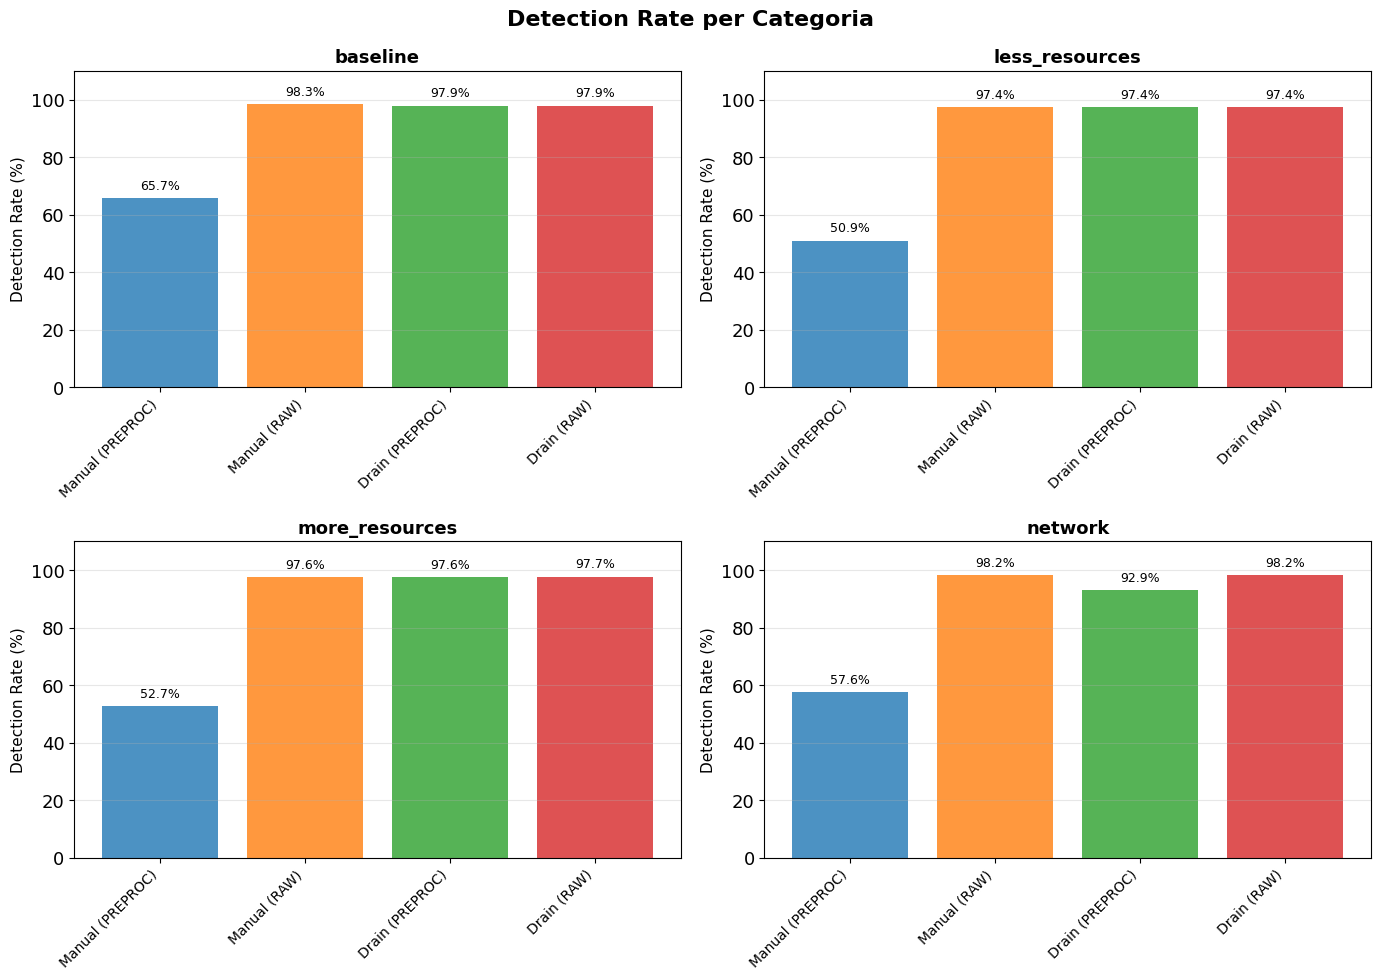

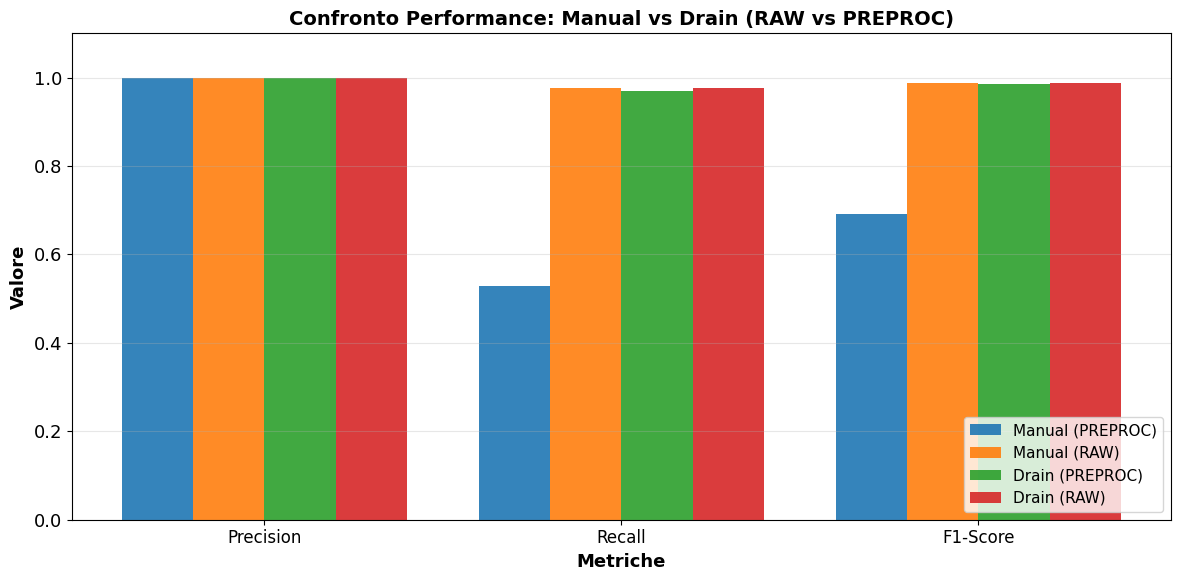

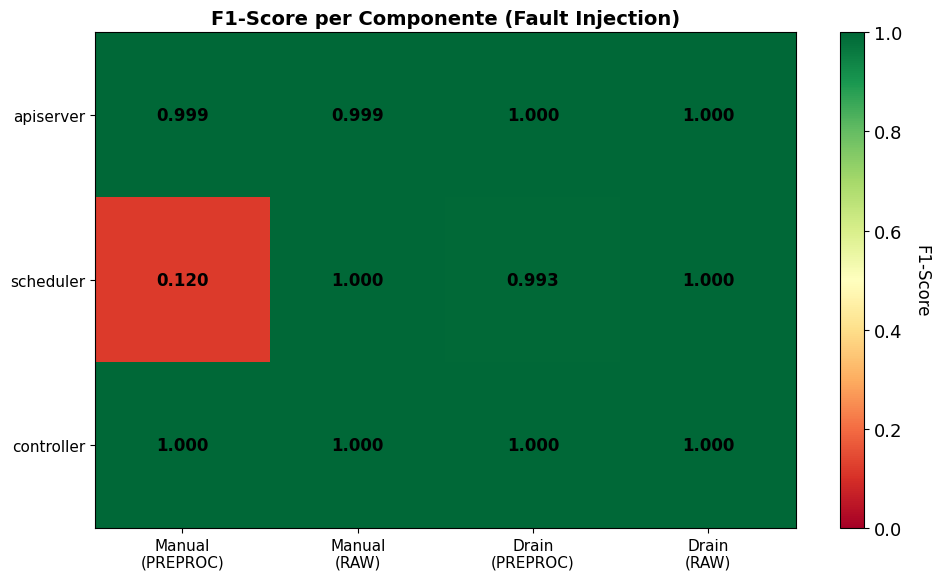

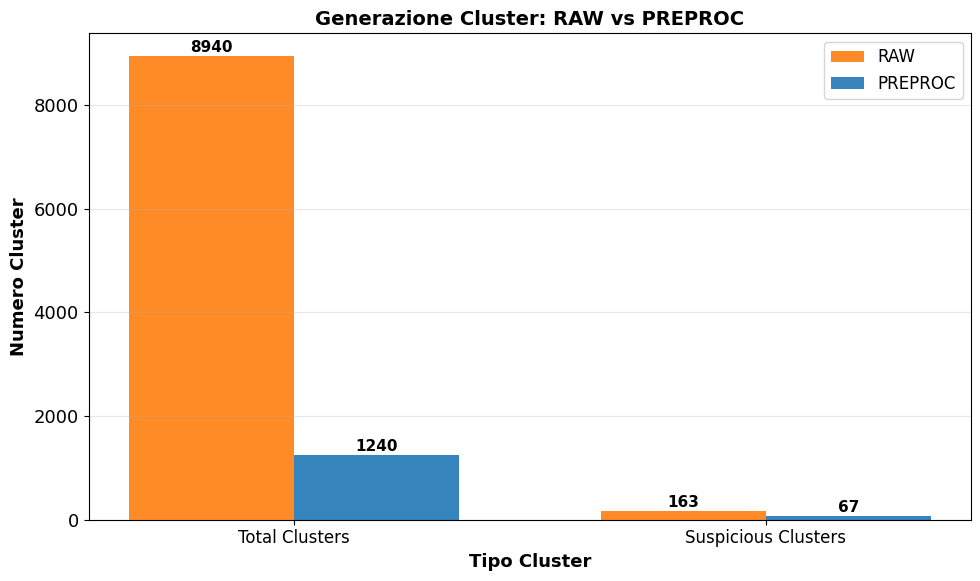


TOP 20 CLUSTER SOSPETTI (PREPROC MODE)

Totale cluster sospetti: 67
Showing top 20:

 1. [CID  54] size=209099 ( 1.4%), keywords=67435 (32.3%)
    Template: <timestamp> stderr F <idate> <*> 1 httplog.go:132] "HTTP" <*> <*> <*> userAgent="kubelet/v1.27.4 (linux/amd64) kubernetes/fa3d799" audit-ID="<audit_id
 2. [CID  13] size=135868 ( 0.9%), keywords=72009 (53.0%)
    Template: <timestamp> stderr F <idate> <*> 1 httplog.go:132] "HTTP" <*> <*> <*> userAgent="kube-controller-manager/v1.27.4 (linux/amd64) <*> audit-ID="<audit_id
 3. [CID  78] size=68860 ( 0.5%), keywords=68455 (99.4%)
    Template: <timestamp> stderr F <idate> <*> 1 httplog.go:132] "HTTP" <*> <*> <*> <*> (linux/amd64) <*> audit-ID="<audit_id>" srcIP="<ip_addr>" <*> <*> apf_iseats
 4. [CID  24] size=41000 ( 0.3%), keywords=3363 ( 8.2%)
    Template: <timestamp> stderr F <idate> <*> 1 httplog.go:132] "HTTP" verb="POST" <*> <*> <*> (linux/amd64) <*> audit-ID="<audit_id>" srcIP="<ip_addr>" <*> <*> ap
 5. [CID 730] size=34662 

In [ ]:
################################################################################
# ANALISI COMPLETA DATASET MUTINY - KUBERNETES LOG PARSING
# Confronto Manual Keyword-Based vs Drain Structure-Based Detection
# Con e Senza Preprocessing
################################################################################

# ============================
# SEZIONE 1: IMPORT E SETUP
# ============================
!pip install drain3

import os
import random
import re
import time
import gc
from collections import defaultdict, Counter
import json
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from drain3 import TemplateMiner
from drain3.file_persistence import FilePersistence
from drain3.template_miner_config import TemplateMinerConfig

from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar

# Configurazione grafici (publication-ready)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.figsize'] = (10, 6)

print("="*80)
print("SCRIPT INIZIALIZZATO CORRETTAMENTE")
print("="*80)

# ============================
# SEZIONE 2: CONFIGURAZIONE
# ============================

# --- Parametri Dataset ---
BASE_DIR = "/content/drive/MyDrive/Mutiny_dataset 2"
CATEGORIES = ["baseline", "less_resources", "more_resources", "network"]
USE_FULL_DATASET = True # True = intero dataset (~2800 file), False = subset test
TEST_SUBSET_SIZE = 50  # File per categoria se USE_FULL_DATASET=False
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Parametri Manual Detection ---
KEYWORDS = ["error", "fail", "failed", "exception", "timeout",
            "panic", "crash", "unavailable", "refused"]
MIN_MANUAL_HITS = 8           # Minimo numero assoluto di keyword per detection
MIN_MANUAL_PCT = 0.003        # Minima percentuale keyword sul totale righe (0.3%)

# --- Parametri Drain ---
DRAIN_SIM_TH = 0.6            # Soglia similarità (0.5-0.7 consigliato)
DRAIN_DEPTH = 4               # Profondità albero Drain
CLUSTER_KEYWORD_PCT = 0.03    # Percentuale minima keyword in cluster (3%)
MIN_CLUSTER_SIZE = 5          # Dimensione minima cluster
MAX_CLUSTER_SIZE_RATIO = 0.08 # Max 8% del totale righe per singolo cluster

# --- Checkpoint ---
CHECKPOINT_ENABLED = True
CHECKPOINT_INTERVAL = 500     # Salva checkpoint ogni N file
CHECKPOINT_DIR = "/content/checkpoints"

print(f"\n{'='*80}")
print("CONFIGURAZIONE PARAMETRI")
print(f"{'='*80}")
print(f"Dataset: {'COMPLETO' if USE_FULL_DATASET else f'SUBSET ({TEST_SUBSET_SIZE} file/categoria)'}")
print(f"Seed riproducibilità: {SEED}")
print(f"Manual detection: MIN_HITS={MIN_MANUAL_HITS}, MIN_PCT={MIN_MANUAL_PCT}")
print(f"Drain: sim_th={DRAIN_SIM_TH}, depth={DRAIN_DEPTH}")
print(f"Cluster filtering: MIN_SIZE={MIN_CLUSTER_SIZE}, MAX_RATIO={MAX_CLUSTER_SIZE_RATIO}, KEYWORD_PCT={CLUSTER_KEYWORD_PCT}")
print(f"Checkpoint: {'ABILITATI' if CHECKPOINT_ENABLED else 'DISABILITATI'} (ogni {CHECKPOINT_INTERVAL} file)")
print(f"{'='*80}\n")

# ============================
# SEZIONE 3: FUNZIONI UTILITY
# ============================

def preprocess_k8s_log(log_line):
    """
    Applica preprocessing a una riga di log Kubernetes.
    Normalizza timestamp, IP, UUID, hash e identificatori variabili,
    mantenendo la semantica del messaggio di errore.

    Args:
        log_line (str): Riga log originale

    Returns:
        str: Riga log preprocessata

    Riferimento: Metodologia preprocessing standard per log strutturati
    """
    if not log_line or not log_line.strip():
        return ""

    content = log_line.strip()

    # Normalizzazione timestamp (formati ISO8601 e varianti)
    content = re.sub(r'^\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}\.\d+([+-]\d{2}:\d{2}|[Zz])?', '<timestamp>', content)
    content = re.sub(r'^\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}([+-]\d{2}:\d{2}|[Zz])?', '<timestamp>', content)
    content = re.sub(r't=\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\.\d+', 't=<timestamp>', content, flags=re.IGNORECASE)
    content = re.sub(r'\d{4}-\d{2}-\d{2}[Tt]\d{2}:\d{2}:\d{2}\.\d+[Zz]?', '<timestamp>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', '<date>', content)
    content = re.sub(r'\b[iI]\d{4}\b', '<idate>', content)

    # Normalizzazione indirizzi IP e porte
    content = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?\b', '<ip_addr>', content)
    content = re.sub(r'\[::1\](:\d+)?', '<ip_addr>', content)
    content = re.sub(r'https?://[^\s/$.?#].[^\s]*', 'https://<ip_addr>', content, flags=re.IGNORECASE)

    # Normalizzazione UUID
    content = re.sub(r'\b[a-f0-9]{8}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{12}\b', '<uuid>', content, flags=re.IGNORECASE)

    # Normalizzazione hash e identificatori lunghi
    content = re.sub(r'\b[a-f0-9]{32,}\b', '<hash>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b[a-f0-9]{16,31}\b', '<hash>', content, flags=re.IGNORECASE)

    # Normalizzazione identificatori Pod, ReplicaSet
    content = re.sub(r'\b([a-zA-Z][a-zA-Z0-9-]*)-[a-f0-9]{5,}(-[a-z0-9]+)?\b', r'\1-<pod_id>', content, flags=re.IGNORECASE)
    content = re.sub(r'\b([a-zA-Z][a-zA-Z0-9-]*)-[a-f0-9]{8,10}\b', r'\1-<rs_id>', content, flags=re.IGNORECASE)

    # Normalizzazione audit ID, UID, resource version
    content = re.sub(r'audit-ID="[^"]*"', 'audit-ID="<audit_id>"', content, flags=re.IGNORECASE)
    content = re.sub(r'uid="[^"]*"', 'uid="<uuid>"', content, flags=re.IGNORECASE)
    content = re.sub(r'resource[vV]ersion[=:]["?\d+"?]?', 'resourceVersion="<res_ver>"', content, flags=re.IGNORECASE)
    content = re.sub(r'node[=:"][^"]*"?', 'node="<node_name>"', content, flags=re.IGNORECASE)

    # Normalizzazione numeri grandi
    content = re.sub(r'\b\d{10,}\b(?![.%])', '<large_num>', content)
    content = re.sub(r'\b\d{8,9}\b(?![.%ms])', '<num_id>', content)

    # Rimozione spazi multipli
    return re.sub(r'\s+', ' ', content).strip()


def collect_all_log_files(base_dir, categories):
    """
    Raccoglie tutti i file di log dal dataset Mutiny.
    Segue la struttura: categoria/scenario/componente/*.log

    Args:
        base_dir (str): Directory radice dataset Mutiny
        categories (list): Lista categorie da processare

    Returns:
        list: Lista path assoluti file log
    """
    all_files = []

    for cat in categories:
        cat_dir = os.path.join(base_dir, cat)
        if not os.path.isdir(cat_dir):
            print(f"[WARNING] Categoria {cat} non trovata in {cat_dir}")
            continue

        # Esplora ricorsivamente tutti i file .log
        for root, dirs, files in os.walk(cat_dir):
            for file in files:
                if file.endswith(".log"):
                    all_files.append(os.path.join(root, file))

    return all_files


def collect_balanced_subset(base_dir, categories, files_per_category):
    """
    Raccoglie subset bilanciato per testing rapido.
    Seleziona N file casuali per categoria.

    Args:
        base_dir (str): Directory radice dataset
        categories (list): Lista categorie
        files_per_category (int): File da selezionare per categoria

    Returns:
        list: Lista path file selezionati
    """
    selected = []

    for cat in categories:
        cat_dir = os.path.join(base_dir, cat)
        if not os.path.isdir(cat_dir):
            continue

        cat_files = []
        for root, dirs, files in os.walk(cat_dir):
            for file in files:
                if file.endswith(".log"):
                    cat_files.append(os.path.join(root, file))

        # Campiona casualmente
        sample_size = min(files_per_category, len(cat_files))
        selected.extend(random.sample(cat_files, sample_size))

    return selected


def manual_detect_rule(matches, total_lines):
    """
    Applica regola di detection manuale keyword-based.
    Un file è considerato anomalo se:
    - Contiene almeno MIN_MANUAL_HITS keyword, OPPURE
    - La percentuale di righe con keyword supera MIN_MANUAL_PCT

    Args:
        matches (int): Numero righe contenenti keyword
        total_lines (int): Numero totale righe file

    Returns:
        bool: True se file rilevato come anomalo
    """
    if matches >= MIN_MANUAL_HITS:
        return True
    if total_lines > 0 and (matches / total_lines) >= MIN_MANUAL_PCT:
        return True
    return False


def compute_binary_metrics(y_true, y_pred):
    """
    Calcola metriche binarie di classificazione.

    Args:
        y_true (array-like): Label ground truth (0=normale, 1=fault)
        y_pred (array-like): Label predette

    Returns:
        dict: Dizionario con tp, fp, fn, tn, precision, recall, f1
    """
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision, "recall": recall, "f1": f1
    }


def save_checkpoint(data, checkpoint_name):
    """Salva checkpoint intermedio."""
    if not CHECKPOINT_ENABLED:
        return

    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{checkpoint_name}.pkl")

    with open(checkpoint_path, 'wb') as f:
        pickle.dump(data, f)

    print(f"  [CHECKPOINT] Salvato: {checkpoint_path}")


def load_checkpoint(checkpoint_name):
    """Carica checkpoint se esistente."""
    if not CHECKPOINT_ENABLED:
        return None

    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{checkpoint_name}.pkl")

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'rb') as f:
            return pickle.load(f)

    return None


# ============================
# SEZIONE 4: FUNZIONE PRINCIPALE ANALISI
# ============================

def run_mode(mode, subset_files, keywords):
    """
    Esegue parsing e detection per modalità specificata (raw o preproc).

    Implementa:
    1. Parsing riga per riga con/senza preprocessing
    2. Detection manuale keyword-based
    3. Clustering Drain con identificazione cluster sospetti
    4. Salvataggio checkpoint automatici

    Args:
        mode (str): "raw" o "preproc"
        subset_files (list): Lista path file da analizzare
        keywords (list): Lista keyword per manual detection

    Returns:
        tuple: (df_results, cluster_info, miner, cluster_total)
            - df_results: DataFrame con risultati per file
            - cluster_info: Dict con info cluster Drain
            - miner: Oggetto TemplateMiner addestrato
            - cluster_total: Counter righe per cluster

    Riferimenti:
        - He et al. (2017): Algoritmo Drain
        - Drain3: Implementazione con persistenza
    """

    print(f"\n{'='*80}")
    print(f"MODALITÀ: {mode.upper()}")
    print(f"{'='*80}")

    # Verifica checkpoint esistente
    checkpoint_data = load_checkpoint(f"run_{mode}")
    if checkpoint_data is not None:
        print(f"[INFO] Checkpoint trovato per modalità {mode}. Ripresa da ultimo salvataggio.")
        return checkpoint_data

    # Configurazione Drain
    config = TemplateMinerConfig()
    config.profiling_enabled = False
    config.drain_sim_th = DRAIN_SIM_TH
    config.drain_depth = DRAIN_DEPTH
    config.max_children = 100

    persistence = FilePersistence(f"drain_state_{mode}_{int(time.time())}.json")
    miner = TemplateMiner(persistence, config)

    # Contatori
    cluster_total = Counter()      # Righe totali per cluster
    cluster_keyword = Counter()    # Righe con keyword per cluster
    records = []                   # Risultati per file

    print(f"\n[{mode.upper()}] Inizio processing di {len(subset_files)} file...")
    start_time = time.time()
    processed = 0

    for file_idx, file_path in enumerate(subset_files):
        file_path = file_path.strip()

        if not os.path.exists(file_path):
            print(f"[WARN] File non trovato: {file_path}")
            continue

        # Contatori per file corrente
        file_lines = 0
        file_manual_matches = 0
        file_cluster_ids = set()

        # Processing riga per riga
        try:
            with open(file_path, "r", errors="ignore") as fh:
                for line in fh:
                    file_lines += 1

                    # Applica preprocessing se richiesto
                    if mode == "preproc":
                        proc = preprocess_k8s_log(line)
                    else:
                        proc = line.strip()

                    if not proc:
                        continue

                    # Manual detection: conta keyword
                    low = proc.lower()
                    if any(k in low for k in keywords):
                        file_manual_matches += 1

                    # Drain clustering
                    result = miner.add_log_message(proc)
                    cid = result.get("cluster_id", None)

                    if cid is not None:
                        file_cluster_ids.add(cid)
                        cluster_total[cid] += 1
                        if any(k in low for k in keywords):
                            cluster_keyword[cid] += 1

        except Exception as e:
            print(f"[ERROR] Errore processing file {file_path}: {e}")
            continue

        # Determina detection manuale
        manual_detected = manual_detect_rule(file_manual_matches, file_lines)

        # Estrai metadati file (categoria, componente)
        cat = next((c for c in CATEGORIES if f"/{c}/" in file_path or f"\\{c}\\" in file_path), "unknown")

        if "kube-apiserver" in file_path:
            comp = "kube-apiserver"
        elif "kube-scheduler" in file_path:
            comp = "kube-scheduler"
        elif "kube-controller-manager" in file_path:
            comp = "kube-controller-manager"
        else:
            comp = "unknown"

        # Salva record
        records.append({
            "file": file_path,
            "category": cat,
            "component": comp,
            "mode": mode,
            "total_lines": file_lines,
            "manual_matches": file_manual_matches,
            "manual_detected": manual_detected,
            "cluster_ids": file_cluster_ids
        })

        processed += 1

        # Progress + Checkpoint
        if processed % 50 == 0:
            elapsed = time.time() - start_time
            avg_time = elapsed / processed
            remaining = (len(subset_files) - processed) * avg_time
            print(f"  Progress: {processed}/{len(subset_files)} files | "
                  f"Elapsed: {elapsed/60:.1f}min | ETA: {remaining/60:.1f}min")

        if CHECKPOINT_ENABLED and processed % CHECKPOINT_INTERVAL == 0:
            partial_data = (records, cluster_total, cluster_keyword, miner)
            save_checkpoint(partial_data, f"run_{mode}_partial_{processed}")
            gc.collect()  # Garbage collection

    # Statistiche clustering
    total_lines_processed = sum(cluster_total.values())
    print(f"\n[{mode.upper()}] Processing completato:")
    print(f"  - File analizzati: {processed}")
    print(f"  - Righe totali: {total_lines_processed:,}")
    print(f"  - Cluster generati: {len(cluster_total)}")
    print(f"  - Tempo totale: {(time.time()-start_time)/60:.1f} minuti")

    # Identificazione cluster sospetti
    suspicious_clusters = set()

    for cid, tot in cluster_total.items():
        kcount = cluster_keyword.get(cid, 0)

        # Filtro 1: dimensione minima
        if tot < MIN_CLUSTER_SIZE:
            continue

        # Filtro 2: esclude cluster troppo grandi (pattern generici)
        if total_lines_processed > 0 and (tot / total_lines_processed) > MAX_CLUSTER_SIZE_RATIO:
            continue

        # Filtro 3: percentuale keyword
        if tot > 0 and (kcount / tot) >= CLUSTER_KEYWORD_PCT:
            suspicious_clusters.add(cid)

    print(f"  - Cluster sospetti identificati: {len(suspicious_clusters)}")

    # Aggiungi info Drain ai record
    for rec in records:
        cids = rec["cluster_ids"]
        rec["drain_num_clusters_seen"] = len(cids)
        rec["drain_num_suspicious_clusters_seen"] = len([c for c in cids if c in suspicious_clusters])
        rec["drain_detected"] = rec["drain_num_suspicious_clusters_seen"] > 0

    # Crea info cluster per analisi
    cluster_info = {}
    for cluster in miner.drain.clusters:
        cluster_info[cluster.cluster_id] = {
            "cluster_id": cluster.cluster_id,
            "size": cluster.size,
            "template": cluster.get_template(),
            "keyword_count": int(cluster_keyword.get(cluster.cluster_id, 0)),
            "is_suspicious": (cluster.cluster_id in suspicious_clusters)
        }

    # Converti in DataFrame
    df = pd.DataFrame(records)

    # Salva checkpoint finale
    final_data = (df, cluster_info, miner, cluster_total)
    save_checkpoint(final_data, f"run_{mode}")

    return df, cluster_info, miner, cluster_total


# ===============================================
# SEZIONE 5: CARICAMENTO DATASET
# ===============================================

print(f"\n{'='*80}")
print("CARICAMENTO DATASET")
print(f"{'='*80}")

if USE_FULL_DATASET:
    print("[INFO] Modalità: DATASET COMPLETO")
    all_files = collect_all_log_files(BASE_DIR, CATEGORIES)
else:
    print(f"[INFO] Modalità: SUBSET TEST ({TEST_SUBSET_SIZE} file/categoria)")
    all_files = collect_balanced_subset(BASE_DIR, CATEGORIES, TEST_SUBSET_SIZE)

print(f"\n✓ Totale file selezionati: {len(all_files)}")

# Statistiche distribuzione
for cat in CATEGORIES:
    count = sum(1 for f in all_files if f"/{cat}/" in f or f"\\{cat}\\" in f)
    print(f"  - {cat:20s}: {count:4d} file ({100*count/len(all_files):.1f}%)")

# ===============================================
# SEZIONE 6: ESECUZIONE ANALISI RAW
# ===============================================

print(f"\n{'='*80}")
print("FASE 1: ANALISI MODALITÀ RAW (log originali)")
print(f"{'='*80}")

t0_raw = time.time()
df_raw, clusters_raw, miner_raw, cluster_total_raw = run_mode("raw", all_files, KEYWORDS)
elapsed_raw = time.time() - t0_raw

print(f"\n✓ Modalità RAW completata in {elapsed_raw/60:.1f} minuti ({elapsed_raw/len(all_files):.2f}s/file)")

# ===============================================
# SEZIONE 7: ESECUZIONE ANALISI PREPROC
# ===============================================

print(f"\n{'='*80}")
print("FASE 2: ANALISI MODALITÀ PREPROC (log normalizzati)")
print(f"{'='*80}")

t0_pre = time.time()
df_pre, clusters_pre, miner_pre, cluster_total_pre = run_mode("preproc", all_files, KEYWORDS)
elapsed_pre = time.time() - t0_pre

print(f"\n✓ Modalità PREPROC completata in {elapsed_pre/60:.1f} minuti ({elapsed_pre/len(all_files):.2f}s/file)")

# ===============================================
# SEZIONE 8: CALCOLO METRICHE
# ===============================================

print(f"\n{'='*80}")
print("CALCOLO METRICHE COMPARATIVE")
print(f"{'='*80}")

# Aggiungi label ground truth (fault injection = categorie LeR, MoR, Net)
df_raw["is_fault_injection"] = df_raw["category"].apply(lambda x: x in ["less_resources", "more_resources", "network"])
df_pre["is_fault_injection"] = df_pre["category"].apply(lambda x: x in ["less_resources", "more_resources", "network"])

# Metriche RAW
fault_mask_raw = df_raw["is_fault_injection"] == True
manual_raw_metrics = compute_binary_metrics(
    df_raw.loc[fault_mask_raw, "is_fault_injection"].astype(int),
    df_raw.loc[fault_mask_raw, "manual_detected"].astype(int)
)
drain_raw_metrics = compute_binary_metrics(
    df_raw.loc[fault_mask_raw, "is_fault_injection"].astype(int),
    df_raw.loc[fault_mask_raw, "drain_detected"].astype(int)
)

# Metriche PREPROC
fault_mask_pre = df_pre["is_fault_injection"] == True
manual_pre_metrics = compute_binary_metrics(
    df_pre.loc[fault_mask_pre, "is_fault_injection"].astype(int),
    df_pre.loc[fault_mask_pre, "manual_detected"].astype(int)
)
drain_pre_metrics = compute_binary_metrics(
    df_pre.loc[fault_mask_pre, "is_fault_injection"].astype(int),
    df_pre.loc[fault_mask_pre, "drain_detected"].astype(int)
)

# ===============================================
# SEZIONE 9: OUTPUT RISULTATI FORMATTATI
# ===============================================

print(f"\n{'='*80}")
print("RISULTATI GLOBALI - CONFRONTO MANUAL vs DRAIN")
print(f"{'='*80}")

print(f"\n{'Metodo':<25} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-"*80)
print(f"{'Manual (RAW)':<25} | {manual_raw_metrics['precision']:>10.3f} | {manual_raw_metrics['recall']:>10.3f} | {manual_raw_metrics['f1']:>10.3f}")
print(f"{'Manual (PREPROC)':<25} | {manual_pre_metrics['precision']:>10.3f} | {manual_pre_metrics['recall']:>10.3f} | {manual_pre_metrics['f1']:>10.3f}")
print(f"{'Δ Manual (R-P)':<25} | {manual_raw_metrics['precision']-manual_pre_metrics['precision']:>+10.3f} | {manual_raw_metrics['recall']-manual_pre_metrics['recall']:>+10.3f} | {manual_raw_metrics['f1']-manual_pre_metrics['f1']:>+10.3f}")
print("-"*80)
print(f"{'Drain (RAW)':<25} | {drain_raw_metrics['precision']:>10.3f} | {drain_raw_metrics['recall']:>10.3f} | {drain_raw_metrics['f1']:>10.3f}")
print(f"{'Drain (PREPROC)':<25} | {drain_pre_metrics['precision']:>10.3f} | {drain_pre_metrics['recall']:>10.3f} | {drain_pre_metrics['f1']:>10.3f}")
print(f"{'Δ Drain (R-P)':<25} | {drain_raw_metrics['precision']-drain_pre_metrics['precision']:>+10.3f} | {drain_raw_metrics['recall']-drain_pre_metrics['recall']:>+10.3f} | {drain_raw_metrics['f1']-drain_pre_metrics['f1']:>+10.3f}")
print("="*80)

# Detection rate per categoria
print(f"\n{'='*80}")
print("DETECTION RATE PER CATEGORIA")
print(f"{'='*80}")

for cat in CATEGORIES:
    mask_raw = df_raw["category"] == cat
    mask_pre = df_pre["category"] == cat
    n_files = mask_raw.sum()

    manual_raw_rate = df_raw.loc[mask_raw, "manual_detected"].mean()
    manual_pre_rate = df_pre.loc[mask_pre, "manual_detected"].mean()
    drain_raw_rate = df_raw.loc[mask_raw, "drain_detected"].mean()
    drain_pre_rate = df_pre.loc[mask_pre, "drain_detected"].mean()

    print(f"\n{cat} ({n_files} file):")
    print(f"  Manual: {manual_pre_rate:5.1%} (preproc) vs {manual_raw_rate:5.1%} (raw) → Δ={manual_raw_rate-manual_pre_rate:+5.1%}")
    print(f"  Drain:  {drain_pre_rate:5.1%} (preproc) vs {drain_raw_rate:5.1%} (raw) → Δ={drain_raw_rate-drain_pre_rate:+5.1%}")

# Performance per componente
print(f"\n{'='*80}")
print("PERFORMANCE PER COMPONENTE (solo fault injection)")
print(f"{'='*80}")

for comp in ["kube-apiserver", "kube-scheduler", "kube-controller-manager"]:
    mask_raw = (df_raw["component"] == comp) & (df_raw["is_fault_injection"] == True)
    mask_pre = (df_pre["component"] == comp) & (df_pre["is_fault_injection"] == True)
    n_files = mask_raw.sum()

    if n_files < 5:
        print(f"\n{comp}: skipped (solo {n_files} file)")
        continue

    # Manual
    manual_raw_comp = compute_binary_metrics(
        df_raw.loc[mask_raw, "is_fault_injection"].astype(int),
        df_raw.loc[mask_raw, "manual_detected"].astype(int)
    )
    manual_pre_comp = compute_binary_metrics(
        df_pre.loc[mask_pre, "is_fault_injection"].astype(int),
        df_pre.loc[mask_pre, "manual_detected"].astype(int)
    )

    # Drain
    drain_raw_comp = compute_binary_metrics(
        df_raw.loc[mask_raw, "is_fault_injection"].astype(int),
        df_raw.loc[mask_raw, "drain_detected"].astype(int)
    )
    drain_pre_comp = compute_binary_metrics(
        df_pre.loc[mask_pre, "is_fault_injection"].astype(int),
        df_pre.loc[mask_pre, "drain_detected"].astype(int)
    )

    print(f"\n{comp} ({n_files} file):")
    print(f"  Manual (RAW):    P={manual_raw_comp['precision']:.3f}, R={manual_raw_comp['recall']:.3f}, F1={manual_raw_comp['f1']:.3f}")
    print(f"  Manual (PREPROC): P={manual_pre_comp['precision']:.3f}, R={manual_pre_comp['recall']:.3f}, F1={manual_pre_comp['f1']:.3f}")
    print(f"  Drain (RAW):     P={drain_raw_comp['precision']:.3f}, R={drain_raw_comp['recall']:.3f}, F1={drain_raw_comp['f1']:.3f}")
    print(f"  Drain (PREPROC):  P={drain_pre_comp['precision']:.3f}, R={drain_pre_comp['recall']:.3f}, F1={drain_pre_comp['f1']:.3f}")

# Cluster statistics
print(f"\n{'='*80}")
print("CLUSTER GENERATION: RAW vs PREPROC")
print(f"{'='*80}")

total_clusters_raw = len(clusters_raw)
total_clusters_pre = len(clusters_pre)
susp_raw = sum(1 for info in clusters_raw.values() if info["is_suspicious"])
susp_pre = sum(1 for info in clusters_pre.values() if info["is_suspicious"])

print(f"\nCluster totali generati:")
print(f"  RAW:     {total_clusters_raw:4d} cluster ({susp_raw:3d} sospetti)")
print(f"  PREPROC: {total_clusters_pre:4d} cluster ({susp_pre:3d} sospetti)")
print(f"  Δ:       {total_clusters_raw-total_clusters_pre:+4d} cluster ({susp_raw-susp_pre:+3d} sospetti)")

lines_per_cluster_raw = sum(cluster_total_raw.values()) / total_clusters_raw if total_clusters_raw > 0 else 0
lines_per_cluster_pre = sum(cluster_total_pre.values()) / total_clusters_pre if total_clusters_pre > 0 else 0

print(f"\nEfficienza clustering (righe/cluster):")
print(f"  RAW:     {lines_per_cluster_raw:,.1f} righe/cluster")
print(f"  PREPROC: {lines_per_cluster_pre:,.1f} righe/cluster")

# Test statistici
print(f"\n{'='*80}")
print("TEST STATISTICI")
print(f"{'='*80}")

# McNemar: Manual vs Drain (PREPROC)
a = int(((df_pre["manual_detected"]) & (df_pre["drain_detected"])).sum())
b = int(((df_pre["manual_detected"]) & (~df_pre["drain_detected"])).sum())
c = int((~(df_pre["manual_detected"]) & (df_pre["drain_detected"])).sum())
d = int((~(df_pre["manual_detected"]) & (~df_pre["drain_detected"])).sum())
table_pre = [[a, b], [c, d]]

print(f"\n1. McNemar Test: Manual vs Drain (PREPROC)")
print(f"   Tabella contingenza: [[{a},{b}],[{c},{d}]]")

try:
    mres = mcnemar(table_pre, exact=False, correction=True)
    print(f"   Statistic: {mres.statistic:.3f}, p-value: {mres.pvalue:.4f}")
    if mres.pvalue < 0.05:
        print(f"   → Differenza SIGNIFICATIVA (p<0.05)")
    else:
        print(f"   → Differenza NON significativa (p≥0.05)")
except Exception as e:
    print(f"   Error: {e}")

# Cohen's Kappa: agreement su baseline
baseline_mask = df_pre["category"] == "baseline"
if baseline_mask.sum() > 0:
    try:
        kappa = cohen_kappa_score(
            df_pre.loc[baseline_mask, "manual_detected"].astype(int),
            df_pre.loc[baseline_mask, "drain_detected"].astype(int)
        )
        print(f"\n2. Cohen's Kappa: Manual vs Drain su BASELINE (PREPROC)")
        print(f"   Kappa: {kappa:.3f}")
        if kappa > 0.8:
            print(f"   → Accordo QUASI PERFETTO")
        elif kappa > 0.6:
            print(f"   → Accordo SOSTANZIALE")
        elif kappa > 0.4:
            print(f"   → Accordo MODERATO")
        else:
            print(f"   → Accordo DEBOLE")
    except Exception as e:
        print(f"   Error: {e}")

# ===============================================
# SEZIONE 10: VISUALIZZAZIONI
# ===============================================

print(f"\n{'='*80}")
print("GENERAZIONE GRAFICI")
print(f"{'='*80}")

# Grafico 1: Detection Rate per Categoria (4 metodi)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Detection Rate per Categoria', fontsize=16, fontweight='bold')

methods = ['Manual (PREPROC)', 'Manual (RAW)', 'Drain (PREPROC)', 'Drain (RAW)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, cat in enumerate(CATEGORIES):
    ax = axes[idx // 2, idx % 2]

    mask_raw = df_raw["category"] == cat
    mask_pre = df_pre["category"] == cat

    rates = [
        df_pre.loc[mask_pre, "manual_detected"].mean() * 100,
        df_raw.loc[mask_raw, "manual_detected"].mean() * 100,
        df_pre.loc[mask_pre, "drain_detected"].mean() * 100,
        df_raw.loc[mask_raw, "drain_detected"].mean() * 100
    ]

    bars = ax.bar(range(len(methods)), rates, color=colors, alpha=0.8)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Detection Rate (%)', fontsize=11)
    ax.set_title(f'{cat}', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 110])
    ax.grid(axis='y', alpha=0.3)

    # Annotazioni
    for bar, rate in zip(bars, rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Grafico 2: Metrics Comparison (Manual vs Drain)
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.2

manual_pre = [manual_pre_metrics['precision'], manual_pre_metrics['recall'], manual_pre_metrics['f1']]
manual_raw = [manual_raw_metrics['precision'], manual_raw_metrics['recall'], manual_raw_metrics['f1']]
drain_pre = [drain_pre_metrics['precision'], drain_pre_metrics['recall'], drain_pre_metrics['f1']]
drain_raw = [drain_raw_metrics['precision'], drain_raw_metrics['recall'], drain_raw_metrics['f1']]

ax.bar(x - 1.5*width, manual_pre, width, label='Manual (PREPROC)', color='#1f77b4', alpha=0.9)
ax.bar(x - 0.5*width, manual_raw, width, label='Manual (RAW)', color='#ff7f0e', alpha=0.9)
ax.bar(x + 0.5*width, drain_pre, width, label='Drain (PREPROC)', color='#2ca02c', alpha=0.9)
ax.bar(x + 1.5*width, drain_raw, width, label='Drain (RAW)', color='#d62728', alpha=0.9)

ax.set_xlabel('Metriche', fontsize=13, fontweight='bold')
ax.set_ylabel('Valore', fontsize=13, fontweight='bold')
ax.set_title('Confronto Performance: Manual vs Drain (RAW vs PREPROC)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim([0, 1.1])
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Grafico 3: Component Heatmap (F1-score)
components = ['apiserver', 'scheduler', 'controller']
f1_matrix = []

for comp_name in ["kube-apiserver", "kube-scheduler", "kube-controller-manager"]:
    mask_raw = (df_raw["component"] == comp_name) & (df_raw["is_fault_injection"] == True)
    mask_pre = (df_pre["component"] == comp_name) & (df_pre["is_fault_injection"] == True)

    if mask_raw.sum() < 3:
        f1_matrix.append([0, 0, 0, 0])
        continue

    m_r = compute_binary_metrics(df_raw.loc[mask_raw, "is_fault_injection"].astype(int),
                                   df_raw.loc[mask_raw, "manual_detected"].astype(int))
    m_p = compute_binary_metrics(df_pre.loc[mask_pre, "is_fault_injection"].astype(int),
                                   df_pre.loc[mask_pre, "manual_detected"].astype(int))
    d_r = compute_binary_metrics(df_raw.loc[mask_raw, "is_fault_injection"].astype(int),
                                   df_raw.loc[mask_raw, "drain_detected"].astype(int))
    d_p = compute_binary_metrics(df_pre.loc[mask_pre, "is_fault_injection"].astype(int),
                                   df_pre.loc[mask_pre, "drain_detected"].astype(int))

    f1_matrix.append([m_p['f1'], m_r['f1'], d_p['f1'], d_r['f1']])

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(f1_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(['Manual\n(PREPROC)', 'Manual\n(RAW)', 'Drain\n(PREPROC)', 'Drain\n(RAW)'], fontsize=11)
ax.set_yticklabels(components, fontsize=11)

ax.set_title('F1-Score per Componente (Fault Injection)', fontsize=14, fontweight='bold')

for i in range(3):
    for j in range(4):
        text = ax.text(j, i, f'{f1_matrix[i][j]:.3f}',
                       ha="center", va="center", color="black", fontsize=12, fontweight='bold')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('F1-Score', rotation=270, labelpad=20, fontsize=12)

plt.tight_layout()
plt.show()

# Grafico 4: Cluster Statistics
fig, ax = plt.subplots(figsize=(10, 6))

categories_cluster = ['Total Clusters', 'Suspicious Clusters']
x = np.arange(len(categories_cluster))
width = 0.35

raw_values = [total_clusters_raw, susp_raw]
pre_values = [total_clusters_pre, susp_pre]

bars1 = ax.bar(x - width/2, raw_values, width, label='RAW', color='#ff7f0e', alpha=0.9)
bars2 = ax.bar(x + width/2, pre_values, width, label='PREPROC', color='#1f77b4', alpha=0.9)

ax.set_xlabel('Tipo Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Numero Cluster', fontsize=13, fontweight='bold')
ax.set_title('Generazione Cluster: RAW vs PREPROC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories_cluster, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Annotazioni
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ===============================================
# SEZIONE 11: TOP CLUSTER SOSPETTI
# ===============================================

print(f"\n{'='*80}")
print("TOP 20 CLUSTER SOSPETTI (PREPROC MODE)")
print(f"{'='*80}")

total_lines_pre = sum(cluster_total_pre.values())
susp_clusters_pre = [(cid, info) for cid, info in clusters_pre.items() if info["is_suspicious"]]
susp_sorted_pre = sorted(susp_clusters_pre, key=lambda x: x[1]["size"], reverse=True)

print(f"\nTotale cluster sospetti: {len(susp_sorted_pre)}")
print(f"Showing top 20:\n")

for i, (cid, info) in enumerate(susp_sorted_pre[:20], 1):
    kw_pct = 100 * info['keyword_count'] / info['size'] if info['size'] > 0 else 0
    size_pct = 100 * info['size'] / total_lines_pre if total_lines_pre > 0 else 0
    print(f"{i:2d}. [CID {cid:3d}] size={info['size']:5d} ({size_pct:4.1f}%), keywords={info['keyword_count']:4d} ({kw_pct:4.1f}%)")
    print(f"    Template: {info['template'][:150]}")

# ===============================================
# SEZIONE 12: ANALISI QUALITATIVA BASELINE
# ===============================================

print(f"\n{'='*80}")
print("ANALISI QUALITATIVA: FILE BASELINE RILEVATI")
print(f"{'='*80}")

baseline_detected = df_pre[(df_pre["category"] == "baseline") & (df_pre["manual_detected"] == True)]

if len(baseline_detected) > 0:
    print(f"\nFile baseline rilevati come anomali: {len(baseline_detected)}/{(df_pre['category']=='baseline').sum()}")
    print("\nTop 10 file baseline con più keyword:")

    top_baseline = baseline_detected.nlargest(10, 'manual_matches')

    for idx, row in top_baseline.iterrows():
        kw_pct = 100 * row['manual_matches'] / row['total_lines'] if row['total_lines'] > 0 else 0
        print(f"\n  File: {os.path.basename(row['file'])}")
        print(f"    Component: {row['component']}")
        print(f"    Keywords: {row['manual_matches']}/{row['total_lines']} ({kw_pct:.2f}%)")
        print(f"    Cluster visti: {row['drain_num_clusters_seen']}")
else:
    print("\nNessun file baseline rilevato come anomalo.")

# ===============================================
# SEZIONE 13: SUMMARY FINALE
# ===============================================

print(f"\n{'='*80}")
print("SUMMARY ESECUZIONE COMPLETA")
print(f"{'='*80}")

print(f"\nDataset:")
print(f"  - File totali analizzati: {len(all_files)}")
print(f"  - Tempo totale esecuzione: {(elapsed_raw + elapsed_pre)/60:.1f} minuti")
print(f"  - Tempo medio per file: {(elapsed_raw + elapsed_pre)/len(all_files)/2:.2f} secondi")

print(f"\nRisultati Chiave:")
print(f"  - Manual (PREPROC): Precision={manual_pre_metrics['precision']:.3f}, Recall={manual_pre_metrics['recall']:.3f}, F1={manual_pre_metrics['f1']:.3f}")
print(f"  - Drain (PREPROC):  Precision={drain_pre_metrics['precision']:.3f}, Recall={drain_pre_metrics['recall']:.3f}, F1={drain_pre_metrics['f1']:.3f}")
print(f"  - Δ Manual vs Drain: Recall={drain_pre_metrics['recall']-manual_pre_metrics['recall']:+.3f}, F1={drain_pre_metrics['f1']-manual_pre_metrics['f1']:+.3f}")

print(f"\nImpatto Preprocessing:")
print(f"  - Manual: Recall {manual_pre_metrics['recall']:.3f} (PREPROC) vs {manual_raw_metrics['recall']:.3f} (RAW) → Δ={manual_raw_metrics['recall']-manual_pre_metrics['recall']:+.3f}")
print(f"  - Drain:  Recall {drain_pre_metrics['recall']:.3f} (PREPROC) vs {drain_raw_metrics['recall']:.3f} (RAW) → Δ={drain_raw_metrics['recall']-drain_pre_metrics['recall']:+.3f}")
print(f"  - Cluster: {total_clusters_pre} (PREPROC) vs {total_clusters_raw} (RAW) → Riduzione {100*(total_clusters_raw-total_clusters_pre)/total_clusters_raw:.1f}%")

print(f"\nTest Statistici:")
print(f"  - McNemar (Manual vs Drain, PREPROC): p={mres.pvalue:.4f}")
print(f"  - Cohen's Kappa (baseline, PREPROC): κ={kappa:.3f}")

print(f"\n{'='*80}")
print("✓ ANALISI COMPLETA")
print(f"{'='*80}\n")

print("\n[INFO] Per salvare i DataFrames in CSV (opzionale):")
print("  df_raw.to_csv('results_raw.csv', index=False)")
print("  df_pre.to_csv('results_preproc.csv', index=False)")

